# DATA PREP

### 0. INSTALACIÓN

In [1]:
!pip -q install sentence-transformers pyarrow xgboost

import os
import json
import random
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

### 1. Configuración

In [2]:
BASE_DIR = "/content/drive/MyDrive/EAFIT/TESIS/RZK"

PRICE_PATH = os.path.join(BASE_DIR, "precios_colombia.csv")
NEWS_PATH  = os.path.join(BASE_DIR, "news_raw_colombia_con_fuente.csv")

OUTPUT_DIR = os.path.join(BASE_DIR, "resultados_modelos_mejorados")
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMB_ARTICLE_PATH = os.path.join(OUTPUT_DIR, "news_con_embeddings.parquet")
EMB_DAILY_PATH   = os.path.join(OUTPUT_DIR, "news_embeddings_daily.parquet")
DATASET_PATH     = os.path.join(OUTPUT_DIR, "dataset_modelo_final.parquet")

RESULTS_PATH     = os.path.join(OUTPUT_DIR, "resultados_comparacion_modelos.csv")
SUMMARY_PATH     = os.path.join(OUTPUT_DIR, "resumen_modelo_ganador.json")

TARGET_COL = "target"

print("Directorio base:", BASE_DIR)
print("Directorio de salida:", OUTPUT_DIR)

Directorio base: /content/drive/MyDrive/EAFIT/TESIS/RZK
Directorio de salida: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados


### 2. Load n val data

In [3]:
prices = pd.read_csv(PRICE_PATH)
news = pd.read_csv(NEWS_PATH)

prices["fecha"] = pd.to_datetime(prices["fecha"], errors="coerce")
news["fecha"] = pd.to_datetime(news["fecha"], errors="coerce")

prices = prices.dropna(subset=["fecha", "stock", TARGET_COL]).copy()
news = news.dropna(subset=["fecha", "stock"]).copy()

prices["stock"] = prices["stock"].astype(str)
news["stock"] = news["stock"].astype(str)

prices[TARGET_COL] = prices[TARGET_COL].astype(int)

prices = prices.sort_values(["stock", "fecha"]).reset_index(drop=True)
news = news.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("Precios:", prices.shape)
print("Noticias:", news.shape)

print("\nColumnas precios:")
print(prices.columns.tolist())

print("\nColumnas noticias:")
print(news.columns.tolist())

print("\nRango precios:", prices["fecha"].min(), "->", prices["fecha"].max())
print("Rango noticias:", news["fecha"].min(), "->", news["fecha"].max())

print("\nDistribución target:")
display(prices[TARGET_COL].value_counts(normalize=True).rename("proporción"))

Precios: (5008, 12)
Noticias: (5477, 18)

Columnas precios:
['fecha', 'stock', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'volatility_5', 'ma_5', 'ma_10', 'target']

Columnas noticias:
['stock', 'query', 'published_feed', 'title_feed', 'summary_feed', 'link_google_news', 'final_url', 'domain', 'is_priority_source', 'title_final', 'text_final', 'publish_final', 'is_relevant', 'fecha', 'text_for_sentiment', 'sentiment_label', 'sentiment_score', 'source_name']

Rango precios: 2021-01-14 00:00:00 -> 2025-12-31 00:00:00
Rango noticias: 2021-01-15 00:00:00 -> 2025-12-30 00:00:00

Distribución target:


,proporción
target,
0,0.559904
1,0.440096


### 3. Sentimiento diario

In [4]:
news_model = news.copy()

if "is_relevant" in news_model.columns:
    news_model = news_model[news_model["is_relevant"] == True].copy()

if "sentiment_score" not in news_model.columns:
    label_map = {
        "NEG": -1,
        "NEU": 0,
        "POS": 1,
        "negative": -1,
        "neutral": 0,
        "positive": 1,
        "negativo": -1,
        "neutro": 0,
        "positivo": 1,
    }
    news_model["sentiment_score"] = news_model["sentiment_label"].map(label_map).fillna(0).astype(int)

daily_sent = (
    news_model
    .groupby(["fecha", "stock"])
    .agg(
        n_news=("sentiment_score", "count"),
        sentiment_mean=("sentiment_score", "mean"),
        sentiment_sum=("sentiment_score", "sum"),
        sentiment_std=("sentiment_score", "std"),
        n_positive=("sentiment_score", lambda x: (x > 0).sum()),
        n_negative=("sentiment_score", lambda x: (x < 0).sum()),
        n_neutral=("sentiment_score", lambda x: (x == 0).sum()),
    )
    .reset_index()
)

daily_sent["sentiment_std"] = daily_sent["sentiment_std"].fillna(0)

daily_sent["positive_ratio"] = daily_sent["n_positive"] / daily_sent["n_news"]
daily_sent["negative_ratio"] = daily_sent["n_negative"] / daily_sent["n_news"]
daily_sent["neutral_ratio"]  = daily_sent["n_neutral"]  / daily_sent["n_news"]

display(daily_sent.head())
print("Sentimiento diario:", daily_sent.shape)

,fecha,stock,n_news,sentiment_mean,sentiment_sum,sentiment_std,n_positive,n_negative,n_neutral,positive_ratio,negative_ratio,neutral_ratio
0,2021-01-15,EC,1,0.0,0,0.0,0,0,1,0.0,0.0,1.0
1,2021-01-19,EC,3,0.0,0,0.0,0,0,3,0.0,0.0,1.0
2,2021-01-20,EC,1,0.0,0,0.0,0,0,1,0.0,0.0,1.0
3,2021-01-22,EC,1,0.0,0,0.0,0,0,1,0.0,0.0,1.0
4,2021-01-24,EC,1,0.0,0,0.0,0,0,1,0.0,0.0,1.0


Sentimiento diario: (1576, 12)


### 4. Agregación diaria sentimiento

In [5]:
from sentence_transformers import SentenceTransformer

news_emb = news_model.copy()

def build_text_for_embedding(row):
    parts = []

    for col in ["title_final", "title_feed", "summary_feed", "text_for_sentiment"]:
        if col in row.index and pd.notna(row[col]):
            txt = str(row[col]).strip()
            if txt:
                parts.append(txt)

    return " | ".join(parts)

news_emb["text_for_embedding"] = news_emb.apply(build_text_for_embedding, axis=1)
news_emb["text_for_embedding"] = news_emb["text_for_embedding"].fillna("").astype(str)

news_emb = news_emb[news_emb["text_for_embedding"].str.len() > 5].copy()

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedder = SentenceTransformer(MODEL_NAME)

texts = news_emb["text_for_embedding"].tolist()

embeddings = embedder.encode(
    texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

emb_cols = [f"emb_{i:03d}" for i in range(embeddings.shape[1])]

emb_df = pd.DataFrame(embeddings, columns=emb_cols)

news_emb = pd.concat(
    [news_emb.reset_index(drop=True), emb_df.reset_index(drop=True)],
    axis=1
)

news_emb.to_parquet(EMB_ARTICLE_PATH, index=False)

print("Noticias con embeddings:", news_emb.shape)
print("Dimensión embeddings:", len(emb_cols))
print("Guardado en:", EMB_ARTICLE_PATH)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/343 [00:00<?, ?it/s]

Noticias con embeddings: (5477, 403)
Dimensión embeddings: 384
Guardado en: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/news_con_embeddings.parquet


### 5. Agregación de embedding


In [6]:
emb_cols = [c for c in news_emb.columns if c.startswith("emb_")]

agg_dict = {c: "mean" for c in emb_cols}
agg_dict["text_for_embedding"] = "count"

daily_emb = (
    news_emb
    .groupby(["fecha", "stock"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"text_for_embedding": "n_news_emb"})
)

daily_emb.to_parquet(EMB_DAILY_PATH, index=False)

print("Embeddings diarios:", daily_emb.shape)
display(daily_emb.head())

Embeddings diarios: (1576, 387)


,fecha,stock,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,emb_007,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,n_news_emb
0,2021-01-15,EC,0.015660,0.070591,0.041736,-0.055617,0.099653,-0.043734,0.025728,0.029124,...,0.022899,-0.039061,-0.074538,-0.016860,0.004007,0.028887,-0.019651,0.094129,0.050225,1
1,2021-01-19,EC,0.034889,0.014757,-0.014176,-0.050004,0.052389,-0.019064,0.052994,0.048041,...,-0.059742,-0.027457,-0.048637,-0.077121,-0.009775,0.044267,-0.083219,0.007491,0.081526,3
2,2021-01-20,EC,0.028927,-0.034954,0.045450,-0.022618,0.105978,-0.016165,0.010244,0.031063,...,-0.093865,-0.067429,0.008918,-0.084467,-0.045305,0.069946,-0.109463,0.004397,0.049610,1
3,2021-01-22,EC,0.074289,0.083013,0.054770,-0.057582,0.017369,-0.018351,-0.029334,-0.024392,...,-0.025375,-0.053963,-0.025600,-0.036483,0.000499,0.024285,-0.044307,-0.039326,0.046565,1
4,2021-01-24,EC,-0.025083,0.013500,0.070952,0.040423,0.069306,-0.029745,0.022200,0.046736,...,-0.108333,-0.093742,0.015024,-0.037137,-0.082102,0.073794,-0.034032,0.048634,0.033308,1


### 6. Consolidación dataset

In [7]:
df = prices.copy()

df = df.merge(
    daily_sent,
    on=["fecha", "stock"],
    how="left"
)

df = df.merge(
    daily_emb,
    on=["fecha", "stock"],
    how="left"
)

sent_cols = [
    "n_news",
    "sentiment_mean",
    "sentiment_sum",
    "sentiment_std",
    "n_positive",
    "n_negative",
    "n_neutral",
    "positive_ratio",
    "negative_ratio",
    "neutral_ratio",
]

for col in sent_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

emb_cols = [c for c in df.columns if c.startswith("emb_")]

for col in emb_cols:
    df[col] = df[col].fillna(0.0)

if "n_news_emb" in df.columns:
    df["n_news_emb"] = df["n_news_emb"].fillna(0)

df = df.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("Dataset final:", df.shape)
display(df.head())

df.to_parquet(DATASET_PATH, index=False)

Dataset final: (5008, 407)


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,n_news_emb
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,0.019665,0.018500,11147.582227,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-15,ARG,14000.0,14100.0,13800.0,11268.315430,108784,0.000000,0.012302,11179.777539,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-18,ARG,13900.0,13900.0,13670.0,11187.826172,117277,-0.007143,0.013117,11195.875000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-19,ARG,13960.0,14000.0,13840.0,11236.117188,46560,0.004316,0.012656,11202.313867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-20,ARG,13900.0,13960.0,13840.0,11187.826172,129726,-0.004298,0.010528,11229.680078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 7. Feature engineering temporal

In [8]:
df_model = df.copy()

df_model["year"] = df_model["fecha"].dt.year
df_model["month"] = df_model["fecha"].dt.month
df_model["day"] = df_model["fecha"].dt.day
df_model["dayofweek"] = df_model["fecha"].dt.dayofweek
df_model["quarter"] = df_model["fecha"].dt.quarter
df_model["is_month_start"] = df_model["fecha"].dt.is_month_start.astype(int)
df_model["is_month_end"] = df_model["fecha"].dt.is_month_end.astype(int)

# Lags de retornos y target
for lag in [1, 2, 3, 5, 10]:
    df_model[f"return_lag_{lag}"] = df_model.groupby("stock")["return_1d"].shift(lag)
    df_model[f"target_lag_{lag}"] = df_model.groupby("stock")[TARGET_COL].shift(lag)

# Rolling features
for window in [3, 5, 10, 20]:
    df_model[f"return_roll_mean_{window}"] = (
        df_model.groupby("stock")["return_1d"]
        .shift(1)
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df_model[f"return_roll_std_{window}"] = (
        df_model.groupby("stock")["return_1d"]
        .shift(1)
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df_model[f"volume_roll_mean_{window}"] = (
        df_model.groupby("stock")["volume"]
        .shift(1)
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

# Variables derivadas de precio
df_model["high_low_range"] = (df_model["high"] - df_model["low"]) / df_model["close"]
df_model["open_close_range"] = (df_model["close"] - df_model["open"]) / df_model["open"]

df_model = df_model.replace([np.inf, -np.inf], np.nan)

df_model = df_model.dropna(subset=[TARGET_COL]).copy()

print("Dataset modelado:", df_model.shape)
display(df_model.head())

Dataset modelado: (5008, 438)


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,...,return_roll_std_5,volume_roll_mean_5,return_roll_mean_10,return_roll_std_10,volume_roll_mean_10,return_roll_mean_20,return_roll_std_20,volume_roll_mean_20,high_low_range,open_close_range
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,0.019665,0.018500,11147.582227,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035498,-0.195120
1,2021-01-15,ARG,14000.0,14100.0,13800.0,11268.315430,108784,0.000000,0.012302,11179.777539,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026623,-0.195120
2,2021-01-18,ARG,13900.0,13900.0,13670.0,11187.826172,117277,-0.007143,0.013117,11195.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020558,-0.195120
3,2021-01-19,ARG,13960.0,14000.0,13840.0,11236.117188,46560,0.004316,0.012656,11202.313867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014240,-0.195121
4,2021-01-20,ARG,13900.0,13960.0,13840.0,11187.826172,129726,-0.004298,0.010528,11229.680078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010726,-0.195120


# TRAINING / CLASSIC

### 8. SPLIT para entrenamiento

In [9]:
unique_dates = np.array(sorted(df_model["fecha"].unique()))

train_cut = int(len(unique_dates) * 0.70)
val_cut   = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_cut]
val_dates   = unique_dates[train_cut:val_cut]
test_dates  = unique_dates[val_cut:]

train_df = df_model[df_model["fecha"].isin(train_dates)].copy()
val_df   = df_model[df_model["fecha"].isin(val_dates)].copy()
test_df  = df_model[df_model["fecha"].isin(test_dates)].copy()

print("Train:", train_df["fecha"].min(), "->", train_df["fecha"].max(), train_df.shape)
print("Val:", val_df["fecha"].min(), "->", val_df["fecha"].max(), val_df.shape)
print("Test:", test_df["fecha"].min(), "->", test_df["fecha"].max(), test_df.shape)

print("\nDistribución target train:")
display(train_df[TARGET_COL].value_counts(normalize=True))

print("\nDistribución target val:")
display(val_df[TARGET_COL].value_counts(normalize=True))

print("\nDistribución target test:")
display(test_df[TARGET_COL].value_counts(normalize=True))

Train: 2021-01-14 00:00:00 -> 2024-07-03 00:00:00 (3515, 438)
Val: 2024-07-04 00:00:00 -> 2025-04-02 00:00:00 (750, 438)
Test: 2025-04-03 00:00:00 -> 2025-12-31 00:00:00 (743, 438)

Distribución target train:


,proportion
target,
0,0.558464
1,0.441536



Distribución target val:


,proportion
target,
0,0.569333
1,0.430667



Distribución target test:


,proportion
target,
0,0.557201
1,0.442799


### 9. Funciones de evaluación

In [10]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    confusion_matrix,
)

def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)

    best_thr = 0.50
    best_mcc = -999

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = thr

    return best_thr, best_mcc


def evaluate_predictions(y_true, y_prob=None, y_pred=None, threshold=0.50):
    if y_pred is None:
        y_pred = (y_prob >= threshold).astype(int)

    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "threshold": threshold,
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            result["roc_auc"] = roc_auc_score(y_true, y_prob)
        except:
            result["roc_auc"] = np.nan
    else:
        result["roc_auc"] = np.nan

    return result


def add_result(results, model_name, scenario, split, metrics):
    row = {
        "model": model_name,
        "scenario": scenario,
        "split": split,
    }

    row.update(metrics)
    results.append(row)

### 10. Definición de escenarios

In [11]:
exclude_cols = [
    "fecha",
    TARGET_COL,
    "title_feed",
    "summary_feed",
    "title_final",
    "text_final",
    "text_for_sentiment",
    "text_for_embedding",
    "query",
    "published_feed",
    "link_google_news",
    "final_url",
    "domain",
    "publish_final",
    "source_name",
    "sentiment_label",
]

all_cols = df_model.columns.tolist()

technical_features = [
    c for c in all_cols
    if c not in exclude_cols
    and not c.startswith("emb_")
    and c not in sent_cols
]

sentiment_features = technical_features + [
    c for c in sent_cols
    if c in df_model.columns
]

embedding_features = sentiment_features + emb_cols

print("Features técnicas:", len(technical_features))
print("Features con sentimiento:", len(sentiment_features))
print("Features con embeddings:", len(embedding_features))

print("\nEjemplo features técnicas:")
print(technical_features[:20])

Features técnicas: 42
Features con sentimiento: 52
Features con embeddings: 436

Ejemplo features técnicas:
['stock', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'volatility_5', 'ma_5', 'ma_10', 'n_news_emb', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_month_start', 'is_month_end', 'return_lag_1', 'target_lag_1']


### 11. Modelos "clásicos"

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from xgboost import XGBClassifier

results = []

def build_preprocessor(features):
    categorical_features = [c for c in features if c == "stock"]
    numeric_features = [c for c in features if c != "stock"]

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ]
    )

    return preprocessor


classic_models = {
    "Dummy_Most_Frequent": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Dummy_Stratified": DummyClassifier(strategy="stratified", random_state=SEED),

    "Logistic_Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random_Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),

    "Gradient_Boosting": GradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.005,
        subsample=0.80,
        colsample_bytree=0.80,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    ),
}


scenarios = {
    "A_tecnico": technical_features,
    "B_sentimiento_agregado": sentiment_features,
    "C_embeddings": embedding_features,
}


for scenario_name, features in scenarios.items():

    print("\n" + "=" * 80)
    print("ESCENARIO:", scenario_name)
    print("=" * 80)

    X_train = train_df[features].copy()
    y_train = train_df[TARGET_COL].copy()

    X_val = val_df[features].copy()
    y_val = val_df[TARGET_COL].copy()

    X_test = test_df[features].copy()
    y_test = test_df[TARGET_COL].copy()

    for model_name, model in classic_models.items():

        print("Entrenando:", model_name)

        pipe = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor(features)),
                ("model", model),
            ]
        )

        pipe.fit(X_train, y_train)

        if hasattr(pipe.named_steps["model"], "predict_proba"):
            val_prob = pipe.predict_proba(X_val)[:, 1]
            test_prob = pipe.predict_proba(X_test)[:, 1]

            best_thr, best_val_mcc = find_best_threshold(y_val, val_prob)

            val_metrics = evaluate_predictions(y_val, y_prob=val_prob, threshold=best_thr)
            test_metrics = evaluate_predictions(y_test, y_prob=test_prob, threshold=best_thr)

        else:
            val_pred = pipe.predict(X_val)
            test_pred = pipe.predict(X_test)

            val_metrics = evaluate_predictions(y_val, y_pred=val_pred)
            test_metrics = evaluate_predictions(y_test, y_pred=test_pred)

        add_result(results, model_name, scenario_name, "validation", val_metrics)
        add_result(results, model_name, scenario_name, "test", test_metrics)


### Isolation Forest
for scenario_name, features in scenarios.items():

    print("\nEntrenando Isolation Forest:", scenario_name)

    X_train = train_df[features].copy()
    y_train = train_df[TARGET_COL].copy()

    X_val = val_df[features].copy()
    y_val = val_df[TARGET_COL].copy()

    X_test = test_df[features].copy()
    y_test = test_df[TARGET_COL].copy()

    preprocessor = build_preprocessor(features)

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    iso = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=SEED,
        n_jobs=-1
    )

    iso.fit(X_train_proc)

    val_score = -iso.decision_function(X_val_proc)
    test_score = -iso.decision_function(X_test_proc)

    best_thr, best_val_mcc = find_best_threshold(y_val, val_score)

    val_metrics = evaluate_predictions(y_val, y_prob=val_score, threshold=best_thr)
    test_metrics = evaluate_predictions(y_test, y_prob=test_score, threshold=best_thr)

    add_result(results, "Isolation_Forest", scenario_name, "validation", val_metrics)
    add_result(results, "Isolation_Forest", scenario_name, "test", test_metrics)


results_classic_df = pd.DataFrame(results)

display(
    results_classic_df
    .sort_values(["split", "mcc"], ascending=[True, False])
    .head(20)
)


ESCENARIO: A_tecnico
Entrenando: Dummy_Most_Frequent
Entrenando: Dummy_Stratified
Entrenando: Logistic_Regression
Entrenando: Random_Forest
Entrenando: Gradient_Boosting
Entrenando: XGBoost

ESCENARIO: B_sentimiento_agregado
Entrenando: Dummy_Most_Frequent
Entrenando: Dummy_Stratified
Entrenando: Logistic_Regression
Entrenando: Random_Forest
Entrenando: Gradient_Boosting
Entrenando: XGBoost

ESCENARIO: C_embeddings
Entrenando: Dummy_Most_Frequent
Entrenando: Dummy_Stratified
Entrenando: Logistic_Regression
Entrenando: Random_Forest
Entrenando: Gradient_Boosting
Entrenando: XGBoost

Entrenando Isolation Forest: A_tecnico

Entrenando Isolation Forest: B_sentimiento_agregado

Entrenando Isolation Forest: C_embeddings


,model,scenario,split,accuracy,balanced_accuracy,f1,precision,recall,mcc,threshold,roc_auc
29,Logistic_Regression,C_embeddings,test,0.589502,0.582966,0.531490,0.537267,0.525836,0.166326,0.44,0.599115
17,Logistic_Regression,B_sentimiento_agregado,test,0.528937,0.557949,0.604072,0.481081,0.811550,0.132418,0.22,0.567266
5,Logistic_Regression,A_tecnico,test,0.527591,0.556741,0.603390,0.480216,0.811550,0.129888,0.21,0.561708
11,XGBoost,A_tecnico,test,0.524899,0.554326,0.602029,0.478495,0.811550,0.124805,0.34,0.580848
23,XGBoost,B_sentimiento_agregado,test,0.526245,0.554597,0.600000,0.479129,0.802432,0.123901,0.35,0.581766
35,XGBoost,C_embeddings,test,0.526245,0.554285,0.599089,0.479053,0.799392,0.122779,0.34,0.571840
31,Random_Forest,C_embeddings,test,0.512786,0.547201,0.606522,0.472081,0.848024,0.116241,0.32,0.567846
7,Random_Forest,A_tecnico,test,0.537012,0.552090,0.566751,0.483871,0.683891,0.106939,0.41,0.582874
21,Gradient_Boosting,B_sentimiento_agregado,test,0.549125,0.551415,0.528833,0.492147,0.571429,0.102195,0.41,0.573763
33,Gradient_Boosting,C_embeddings,test,0.506057,0.538042,0.594475,0.467014,0.817629,0.090535,0.25,0.560390


### 12. PCA en embeddings

In [13]:
from sklearn.decomposition import PCA

N_PCA = 32

emb_cols = [c for c in df_model.columns if c.startswith("emb_")]

scaler_emb = StandardScaler()
pca = PCA(n_components=N_PCA, random_state=SEED)

train_emb_scaled = scaler_emb.fit_transform(train_df[emb_cols])
val_emb_scaled   = scaler_emb.transform(val_df[emb_cols])
test_emb_scaled  = scaler_emb.transform(test_df[emb_cols])

train_pca = pca.fit_transform(train_emb_scaled)
val_pca   = pca.transform(val_emb_scaled)
test_pca  = pca.transform(test_emb_scaled)

pca_cols = [f"emb_pca_{i:02d}" for i in range(N_PCA)]

for i, col in enumerate(pca_cols):
    train_df[col] = train_pca[:, i]
    val_df[col] = val_pca[:, i]
    test_df[col] = test_pca[:, i]

deep_features_base = [c for c in technical_features if c != "stock"]
deep_features_sent = [c for c in sentiment_features if c != "stock"]
deep_features_emb  = deep_features_sent + pca_cols

print("Varianza explicada PCA:", pca.explained_variance_ratio_.sum())
print("Features deep base:", len(deep_features_base))
print("Features deep sentimiento:", len(deep_features_sent))
print("Features deep embeddings:", len(deep_features_emb))

Varianza explicada PCA: 0.8415115
Features deep base: 41
Features deep sentimiento: 51
Features deep embeddings: 83


### 13. Creación secuencias temporales

In [14]:
from sklearn.preprocessing import StandardScaler

def create_sequences_by_stock(df_input, features, target_col, seq_len=20):
    X_list = []
    y_list = []
    date_list = []
    stock_list = []

    df_input = df_input.sort_values(["stock", "fecha"]).copy()

    for stock, g in df_input.groupby("stock"):
        g = g.sort_values("fecha").reset_index(drop=True)

        X_values = g[features].values
        y_values = g[target_col].values
        dates = g["fecha"].values

        for i in range(seq_len, len(g)):
            X_list.append(X_values[i-seq_len:i])
            y_list.append(y_values[i])
            date_list.append(dates[i])
            stock_list.append(stock)

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.int64),
        np.array(date_list),
        np.array(stock_list),
    )


def prepare_deep_data(features, seq_len=20):
    scaler = StandardScaler()

    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()

    train_scaled[features] = scaler.fit_transform(train_scaled[features])
    val_scaled[features] = scaler.transform(val_scaled[features])
    test_scaled[features] = scaler.transform(test_scaled[features])

    X_train, y_train, d_train, s_train = create_sequences_by_stock(
        train_scaled, features, TARGET_COL, seq_len
    )

    combined_train_val = pd.concat([train_scaled, val_scaled], axis=0).sort_values(["stock", "fecha"])
    X_val, y_val, d_val, s_val = create_sequences_by_stock(
        combined_train_val, features, TARGET_COL, seq_len
    )

    val_mask = np.isin(d_val, val_df["fecha"].unique())
    X_val, y_val, d_val, s_val = X_val[val_mask], y_val[val_mask], d_val[val_mask], s_val[val_mask]

    combined_all = pd.concat([train_scaled, val_scaled, test_scaled], axis=0).sort_values(["stock", "fecha"])
    X_test, y_test, d_test, s_test = create_sequences_by_stock(
        combined_all, features, TARGET_COL, seq_len
    )

    test_mask = np.isin(d_test, test_df["fecha"].unique())
    X_test, y_test, d_test, s_test = X_test[test_mask], y_test[test_mask], d_test[test_mask], s_test[test_mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

# DEEP Learning

### 14. CNN n LSTM

In [15]:
import tensorflow as tf

tf.random.set_seed(SEED)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    GlobalMaxPooling1D,
    BatchNormalization,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=False),
        Dropout(0.30),
        Dense(32, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, kernel_size=3, padding="causal", activation="relu"),
        BatchNormalization(),
        Dropout(0.20),
        Conv1D(32, kernel_size=3, padding="causal", activation="relu"),
        GlobalMaxPooling1D(),
        Dense(32, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


deep_scenarios = {
    "D_LSTM_tecnico": deep_features_base,
    "D_LSTM_sentimiento": deep_features_sent,
    "D_LSTM_embeddings": deep_features_emb,
    "D_CNN_tecnico": deep_features_base,
    "D_CNN_sentimiento": deep_features_sent,
    "D_CNN_embeddings": deep_features_emb,
}

SEQ_LEN = 20
EPOCHS = 100
BATCH_SIZE = 16

deep_results = []

for scenario_name, features in deep_scenarios.items():

    print("\n" + "=" * 80)
    print("Entrenando:", scenario_name)
    print("=" * 80)

    X_train, y_train, X_val, y_val, X_test, y_test = prepare_deep_data(
        features,
        seq_len=SEQ_LEN
    )

    print("X_train:", X_train.shape)
    print("X_val:", X_val.shape)
    print("X_test:", X_test.shape)

    if scenario_name.startswith("D_LSTM"):
        model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
        model_name = "LSTM"
    else:
        model = build_cnn(input_shape=(X_train.shape[1], X_train.shape[2]))
        model_name = "CNN1D"

    es = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    val_prob = model.predict(X_val, verbose=0).ravel()
    test_prob = model.predict(X_test, verbose=0).ravel()

    best_thr, best_val_mcc = find_best_threshold(y_val, val_prob)

    val_metrics = evaluate_predictions(y_val, y_prob=val_prob, threshold=best_thr)
    test_metrics = evaluate_predictions(y_test, y_prob=test_prob, threshold=best_thr)

    add_result(deep_results, model_name, scenario_name, "validation", val_metrics)
    add_result(deep_results, model_name, scenario_name, "test", test_metrics)

deep_results_df = pd.DataFrame(deep_results)

display(
    deep_results_df
    .sort_values(["split", "mcc"], ascending=[True, False])
)


Entrenando: D_LSTM_tecnico
X_train: (3435, 20, 41)
X_val: (750, 20, 41)
X_test: (743, 20, 41)

Entrenando: D_LSTM_sentimiento
X_train: (3435, 20, 51)
X_val: (750, 20, 51)
X_test: (743, 20, 51)

Entrenando: D_LSTM_embeddings
X_train: (3435, 20, 83)
X_val: (750, 20, 83)
X_test: (743, 20, 83)

Entrenando: D_CNN_tecnico
X_train: (3435, 20, 41)
X_val: (750, 20, 41)
X_test: (743, 20, 41)

Entrenando: D_CNN_sentimiento
X_train: (3435, 20, 51)
X_val: (750, 20, 51)
X_test: (743, 20, 51)

Entrenando: D_CNN_embeddings
X_train: (3435, 20, 83)
X_val: (750, 20, 83)
X_test: (743, 20, 83)


,model,scenario,split,accuracy,balanced_accuracy,f1,precision,recall,mcc,threshold,roc_auc
1,LSTM,D_LSTM_tecnico,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
3,LSTM,D_LSTM_sentimiento,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
5,LSTM,D_LSTM_embeddings,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
7,CNN1D,D_CNN_tecnico,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
9,CNN1D,D_CNN_sentimiento,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
11,CNN1D,D_CNN_embeddings,test,0.557201,0.5,0.0,0.0,0.0,0.0,0.05,NaN
0,LSTM,D_LSTM_tecnico,validation,0.569333,0.5,0.0,0.0,0.0,0.0,0.05,NaN
2,LSTM,D_LSTM_sentimiento,validation,0.569333,0.5,0.0,0.0,0.0,0.0,0.05,NaN
4,LSTM,D_LSTM_embeddings,validation,0.569333,0.5,0.0,0.0,0.0,0.0,0.05,NaN
6,CNN1D,D_CNN_tecnico,validation,0.569333,0.5,0.0,0.0,0.0,0.0,0.05,NaN


### 15. GNN + LSTM SIN TORCH GEOMETRIC

In [16]:
!pip -q install torch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


#### Matriz de adyacencia

In [17]:
gnn_features = deep_features_emb

stocks = sorted(df_model["stock"].unique().tolist())
stock_to_idx = {s: i for i, s in enumerate(stocks)}

returns_panel = (
    train_df
    .pivot_table(index="fecha", columns="stock", values="return_1d")
    .reindex(columns=stocks)
    .fillna(0)
)

corr = returns_panel.corr().fillna(0).values
adj = np.abs(corr)

np.fill_diagonal(adj, 1.0)

# Normalización A_hat = D^-1/2 A D^-1/2
degree = np.sum(adj, axis=1)
degree_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
adj_norm = degree_inv_sqrt @ adj @ degree_inv_sqrt

A = torch.tensor(adj_norm, dtype=torch.float32).to(device)

print("Stocks:", stocks)
print("Matriz de adyacencia:")
display(pd.DataFrame(adj_norm, index=stocks, columns=stocks))

Stocks: ['ARG', 'CIBEST', 'EC', 'NCH']
Matriz de adyacencia:


,ARG,CIBEST,EC,NCH
ARG,0.733487,0.150198,0.102738,0.000197
CIBEST,0.150198,0.648435,0.177843,0.043413
EC,0.102738,0.177843,0.681430,0.042778
NCH,0.000197,0.043413,0.042778,0.899503


Panel de fecha x stock x feature

In [18]:
def build_panel(df_input, features, stocks):
    dates = sorted(df_input["fecha"].unique())

    panel_X = []
    panel_y = []

    for date in dates:
        day = df_input[df_input["fecha"] == date].copy()
        day = day.set_index("stock").reindex(stocks)

        X_day = day[features].fillna(0).values
        y_day = day[TARGET_COL].fillna(0).values

        panel_X.append(X_day)
        panel_y.append(y_day)

    return (
        np.array(panel_X, dtype=np.float32),
        np.array(panel_y, dtype=np.float32),
        np.array(dates),
    )


# Escalado usando solo train
scaler_gnn = StandardScaler()

train_tmp = train_df.copy()
val_tmp = val_df.copy()
test_tmp = test_df.copy()

train_tmp[gnn_features] = scaler_gnn.fit_transform(train_tmp[gnn_features])
val_tmp[gnn_features] = scaler_gnn.transform(val_tmp[gnn_features])
test_tmp[gnn_features] = scaler_gnn.transform(test_tmp[gnn_features])

all_gnn_df = pd.concat([train_tmp, val_tmp, test_tmp], axis=0)
all_gnn_df = all_gnn_df.sort_values(["fecha", "stock"]).copy()

X_panel, y_panel, panel_dates = build_panel(all_gnn_df, gnn_features, stocks)

print("X_panel:", X_panel.shape)
print("y_panel:", y_panel.shape)

X_panel: (1293, 4, 83)
y_panel: (1293, 4)


Dataset de secuencias para GNN n LSTM

In [19]:
class GraphSequenceDataset(Dataset):
    def __init__(self, X_panel, y_panel, dates, selected_dates, seq_len):
        self.X = X_panel
        self.y = y_panel
        self.dates = dates
        self.selected_dates = set(selected_dates)
        self.seq_len = seq_len

        self.indices = []

        for i in range(seq_len, len(dates)):
            if dates[i] in self.selected_dates:
                self.indices.append(i)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        X_seq = self.X[i-self.seq_len:i]
        y_t = self.y[i]

        return (
            torch.tensor(X_seq, dtype=torch.float32),
            torch.tensor(y_t, dtype=torch.float32),
        )


SEQ_LEN_GNN = 20

train_dataset = GraphSequenceDataset(
    X_panel,
    y_panel,
    panel_dates,
    train_df["fecha"].unique(),
    SEQ_LEN_GNN
)

val_dataset = GraphSequenceDataset(
    X_panel,
    y_panel,
    panel_dates,
    val_df["fecha"].unique(),
    SEQ_LEN_GNN
)

test_dataset = GraphSequenceDataset(
    X_panel,
    y_panel,
    panel_dates,
    test_df["fecha"].unique(),
    SEQ_LEN_GNN
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train sequences:", len(train_dataset))
print("Val sequences:", len(val_dataset))
print("Test sequences:", len(test_dataset))

Train sequences: 885
Val sequences: 194
Test sequences: 194


Modelo GNN + LSTM

In [20]:
class GraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, X, A):
        # X: batch, nodes, features
        AX = torch.einsum("ij,bjf->bif", A, X)
        return self.linear(AX)


class GNNLSTM(nn.Module):
    def __init__(self, n_features, hidden_gnn=64, hidden_lstm=64, dropout=0.30):
        super().__init__()

        self.gcn = GraphConv(n_features, hidden_gnn)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=hidden_gnn,
            hidden_size=hidden_lstm,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_lstm, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, X_seq, A):
        # X_seq: batch, seq_len, nodes, features
        B, T, N, F = X_seq.shape

        gcn_outputs = []

        for t in range(T):
            x_t = X_seq[:, t, :, :]
            h_t = self.gcn(x_t, A)
            h_t = self.relu(h_t)
            h_t = self.dropout(h_t)
            gcn_outputs.append(h_t)

        H = torch.stack(gcn_outputs, dim=1)
        # H: batch, seq_len, nodes, hidden_gnn

        H = H.permute(0, 2, 1, 3)
        # batch, nodes, seq_len, hidden_gnn

        H = H.reshape(B * N, T, -1)

        lstm_out, _ = self.lstm(H)
        last_h = lstm_out[:, -1, :]

        logits = self.classifier(last_h).reshape(B, N)

        return logits

Entrenamiento GNN + LSTM

In [21]:
def train_gnn_lstm(model, train_loader, val_loader, A, epochs=500, patience=10):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch, A)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch, A)
                loss = criterion(logits, y_batch)

                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        if epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_state)

    return model


def predict_gnn_lstm(model, loader, A):
    model.eval()

    probs = []
    y_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch, A)
            batch_probs = torch.sigmoid(logits).cpu().numpy()

            probs.append(batch_probs.reshape(-1))
            y_true.append(y_batch.numpy().reshape(-1))

    probs = np.concatenate(probs)
    y_true = np.concatenate(y_true).astype(int)

    return y_true, probs


gnn_model = GNNLSTM(
    n_features=len(gnn_features),
    hidden_gnn=64,
    hidden_lstm=64,
    dropout=0.30
).to(device)

gnn_model = train_gnn_lstm(
    gnn_model,
    train_loader,
    val_loader,
    A,
    epochs=500,
    patience=10
)

y_val_gnn, val_prob_gnn = predict_gnn_lstm(gnn_model, val_loader, A)
y_test_gnn, test_prob_gnn = predict_gnn_lstm(gnn_model, test_loader, A)

best_thr_gnn, best_val_mcc_gnn = find_best_threshold(y_val_gnn, val_prob_gnn)

val_metrics_gnn = evaluate_predictions(
    y_val_gnn,
    y_prob=val_prob_gnn,
    threshold=best_thr_gnn
)

test_metrics_gnn = evaluate_predictions(
    y_test_gnn,
    y_prob=test_prob_gnn,
    threshold=best_thr_gnn
)

gnn_results = []

add_result(
    gnn_results,
    "GNN_LSTM",
    "E_GNN_LSTM_embeddings",
    "validation",
    val_metrics_gnn
)

add_result(
    gnn_results,
    "GNN_LSTM",
    "E_GNN_LSTM_embeddings",
    "test",
    test_metrics_gnn
)

gnn_results_df = pd.DataFrame(gnn_results)

display(gnn_results_df)

Epoch 005 | Train loss: 0.6656 | Val loss: 0.6961
Epoch 010 | Train loss: 0.6389 | Val loss: 0.7085
Early stopping


,model,scenario,split,accuracy,balanced_accuracy,f1,precision,recall,mcc,threshold,roc_auc
0,GNN_LSTM,E_GNN_LSTM_embeddings,validation,0.556701,0.543456,0.465839,0.467290,0.464396,0.086991,0.39,0.542520
1,GNN_LSTM,E_GNN_LSTM_embeddings,test,0.523196,0.506293,0.412698,0.431894,0.395137,0.012765,0.39,0.522803


# RESUMEN

### 16. Resumen general de todos los modelos

,modelo_final,model,scenario,split,accuracy,balanced_accuracy,f1,precision,recall,roc_auc,mcc,threshold
0,Dummy_Most_Frequent | A_tecnico,Dummy_Most_Frequent,A_tecnico,validation,0.569333,0.500000,0.000000,0.000000,0.000000,0.500000,0.000000,0.05
1,Dummy_Most_Frequent | A_tecnico,Dummy_Most_Frequent,A_tecnico,test,0.557201,0.500000,0.000000,0.000000,0.000000,0.500000,0.000000,0.05
2,Dummy_Stratified | A_tecnico,Dummy_Stratified,A_tecnico,validation,0.534667,0.525732,0.460587,0.459877,0.461300,0.525732,0.051445,0.05
3,Dummy_Stratified | A_tecnico,Dummy_Stratified,A_tecnico,test,0.502019,0.494167,0.430769,0.436137,0.425532,0.494167,-0.011698,0.05
4,Logistic_Regression | A_tecnico,Logistic_Regression,A_tecnico,validation,0.505333,0.554640,0.613139,0.462264,0.910217,0.561336,0.150721,0.21


,modelo_final,model,scenario,mcc_validation,mcc_test,balanced_accuracy_validation,balanced_accuracy_test,accuracy_validation,accuracy_test,f1_validation,f1_test,roc_auc_validation,roc_auc_test,precision_validation,precision_test,recall_validation,recall_test,threshold_validation,threshold_test,ranking_mcc_test
0,Logistic_Regression | C_embeddings,Logistic_Regression,C_embeddings,0.114172,0.166326,0.557584,0.582966,0.553333,0.589502,0.531469,0.531490,0.542318,0.599115,0.484694,0.537267,0.588235,0.525836,0.44,0.44,1
1,Logistic_Regression | B_sentimiento_agregado,Logistic_Regression,B_sentimiento_agregado,0.149870,0.132418,0.555851,0.557949,0.508000,0.528937,0.611987,0.604072,0.555796,0.567266,0.463376,0.481081,0.900929,0.811550,0.22,0.22,2
2,Logistic_Regression | A_tecnico,Logistic_Regression,A_tecnico,0.150721,0.129888,0.554640,0.556741,0.505333,0.527591,0.613139,0.603390,0.561336,0.561708,0.462264,0.480216,0.910217,0.811550,0.21,0.21,3
3,XGBoost | A_tecnico,XGBoost,A_tecnico,0.163709,0.124805,0.571769,0.554326,0.536000,0.524899,0.606335,0.602029,0.570218,0.580848,0.477718,0.478495,0.829721,0.811550,0.34,0.34,4
4,XGBoost | B_sentimiento_agregado,XGBoost,B_sentimiento_agregado,0.168464,0.123901,0.574111,0.554597,0.538667,0.526245,0.607710,0.600000,0.570152,0.581766,0.479428,0.479129,0.829721,0.802432,0.35,0.35,5
5,XGBoost | C_embeddings,XGBoost,C_embeddings,0.161827,0.122779,0.570181,0.554285,0.533333,0.526245,0.606742,0.599089,0.563460,0.571840,0.476190,0.479053,0.835913,0.799392,0.34,0.34,6
6,Random_Forest | C_embeddings,Random_Forest,C_embeddings,0.155522,0.116241,0.564624,0.547201,0.524000,0.512786,0.608123,0.606522,0.567281,0.567846,0.471088,0.472081,0.857585,0.848024,0.32,0.32,7
7,Random_Forest | A_tecnico,Random_Forest,A_tecnico,0.177469,0.106939,0.584969,0.552090,0.561333,0.537012,0.597307,0.566751,0.569348,0.582874,0.493927,0.483871,0.755418,0.683891,0.41,0.41,8
8,Gradient_Boosting | B_sentimiento_agregado,Gradient_Boosting,B_sentimiento_agregado,0.155425,0.102195,0.577091,0.551415,0.562667,0.549125,0.572917,0.528833,0.581833,0.573763,0.494382,0.492147,0.681115,0.571429,0.41,0.41,9
9,Gradient_Boosting | C_embeddings,Gradient_Boosting,C_embeddings,0.147174,0.090535,0.560317,0.538042,0.518667,0.506057,0.606325,0.594475,0.562746,0.560390,0.468013,0.467014,0.860681,0.817629,0.25,0.25,10


MEJOR MODELO SEGÚN MCC EN TEST
Modelo final: Logistic_Regression | C_embeddings
Modelo base: Logistic_Regression
Escenario: C_embeddings
MCC test: 0.1663
Balanced Accuracy test: 0.5830
Accuracy test: 0.5895
F1 test: 0.5315
ROC-AUC test: 0.5991

COMPARACIÓN CONTRA LÍNEA BASE
Mejor línea base: Random_Forest | C_embeddings
MCC línea base: 0.1162
MCC mejor modelo: 0.1663
Mejora absoluta en MCC: 0.0501

TOP 15 MODELOS SEGÚN MCC EN TEST


,ranking_mcc_test,modelo_final,mcc_test,balanced_accuracy_test,accuracy_test,f1_test,roc_auc_test
0,1,Logistic_Regression | C_embeddings,0.166326,0.582966,0.589502,0.531490,0.599115
1,2,Logistic_Regression | B_sentimiento_agregado,0.132418,0.557949,0.528937,0.604072,0.567266
2,3,Logistic_Regression | A_tecnico,0.129888,0.556741,0.527591,0.603390,0.561708
3,4,XGBoost | A_tecnico,0.124805,0.554326,0.524899,0.602029,0.580848
4,5,XGBoost | B_sentimiento_agregado,0.123901,0.554597,0.526245,0.600000,0.581766
5,6,XGBoost | C_embeddings,0.122779,0.554285,0.526245,0.599089,0.571840
6,7,Random_Forest | C_embeddings,0.116241,0.547201,0.512786,0.606522,0.567846
7,8,Random_Forest | A_tecnico,0.106939,0.552090,0.537012,0.566751,0.582874
8,9,Gradient_Boosting | B_sentimiento_agregado,0.102195,0.551415,0.549125,0.528833,0.573763
9,10,Gradient_Boosting | C_embeddings,0.090535,0.538042,0.506057,0.594475,0.560390



COMPARACIÓN POR TIPO DE INFORMACIÓN USADA


,tipo_informacion,mejor_mcc_test,promedio_mcc_test,mediana_mcc_test,cantidad_modelos
0,Con embeddings de noticias,0.166326,0.048087,0.006383,10
1,Con sentimiento agregado,0.132418,0.055193,0.067970,9
2,Solo variables técnicas,0.129888,0.051143,0.023560,9


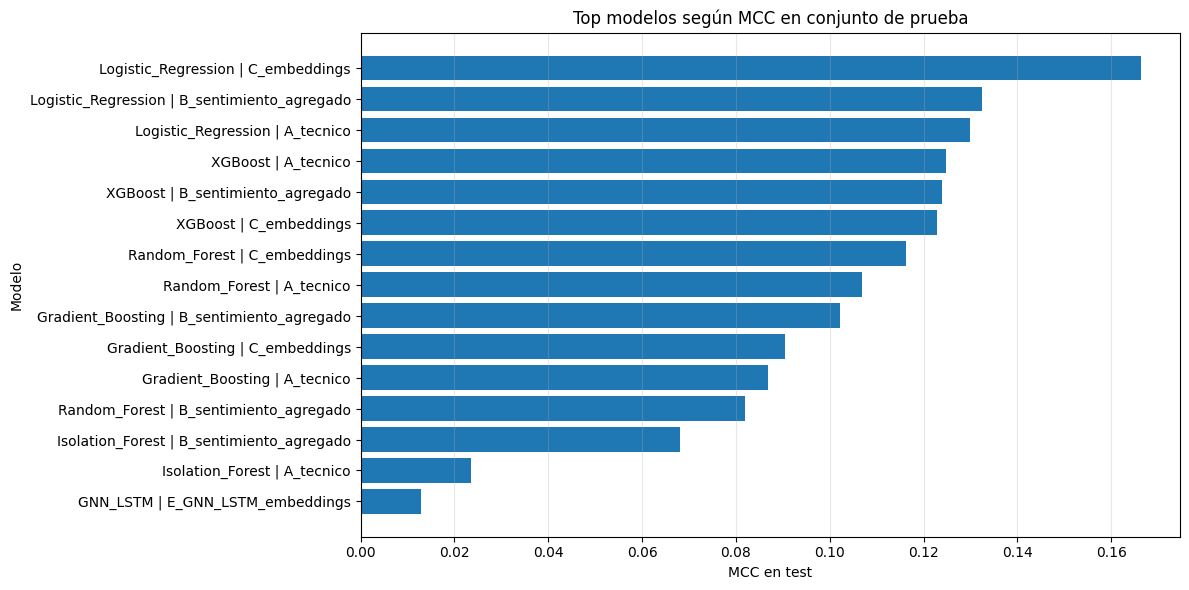


ARCHIVOS GUARDADOS
Resultados completos: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/resultados_comparacion_modelos.csv
Resumen general: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/resumen_todos_los_modelos.csv
Ranking modelos: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/ranking_modelos_mcc_test.csv
Comparación tipo información: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/comparacion_tipo_informacion.csv
Resumen modelo ganador: /content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos_mejorados/modelo_ganador_resumen.json


In [22]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Consolidación

all_results = []

if "results_classic_df" in globals():
    all_results.append(results_classic_df)

if "deep_results_df" in globals():
    all_results.append(deep_results_df)

if "gnn_results_df" in globals():
    all_results.append(gnn_results_df)

if len(all_results) == 0:
    raise ValueError("No se encontraron dataframes de resultados. Verifica que existan results_classic_df, deep_results_df o gnn_results_df.")

results_all_df = pd.concat(all_results, ignore_index=True)

### Normalización
results_all_df["model"] = results_all_df["model"].astype(str)
results_all_df["scenario"] = results_all_df["scenario"].astype(str)
results_all_df["split"] = results_all_df["split"].astype(str)

### Identificador
results_all_df["modelo_final"] = results_all_df["model"] + " | " + results_all_df["scenario"]

### Orden asignado
cols_order = [
    "modelo_final",
    "model",
    "scenario",
    "split",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "mcc",
    "threshold"
]

cols_order = [c for c in cols_order if c in results_all_df.columns]
results_all_df = results_all_df[cols_order]

display(results_all_df.head())

### Separación por momento
summary_df = (
    results_all_df
    .pivot_table(
        index=["modelo_final", "model", "scenario"],
        columns="split",
        values=["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc", "mcc", "threshold"],
        aggfunc="first"
    )
)


summary_df.columns = [f"{metric}_{split}" for metric, split in summary_df.columns]
summary_df = summary_df.reset_index()

main_cols = [
    "modelo_final",
    "model",
    "scenario",
    "mcc_validation",
    "mcc_test",
    "balanced_accuracy_validation",
    "balanced_accuracy_test",
    "accuracy_validation",
    "accuracy_test",
    "f1_validation",
    "f1_test",
    "roc_auc_validation",
    "roc_auc_test",
    "precision_validation",
    "precision_test",
    "recall_validation",
    "recall_test",
    "threshold_validation",
    "threshold_test"
]

main_cols = [c for c in main_cols if c in summary_df.columns]
summary_df = summary_df[main_cols]

### Ranking según MCC
summary_df = summary_df.sort_values("mcc_test", ascending=False).reset_index(drop=True)
summary_df["ranking_mcc_test"] = np.arange(1, len(summary_df) + 1)

display(summary_df)

### Best model
best_model_row = summary_df.iloc[0].to_dict()

print("=" * 90)
print("MEJOR MODELO SEGÚN MCC EN TEST")
print("=" * 90)
print(f"Modelo final: {best_model_row['modelo_final']}")
print(f"Modelo base: {best_model_row['model']}")
print(f"Escenario: {best_model_row['scenario']}")
print(f"MCC test: {best_model_row.get('mcc_test', np.nan):.4f}")
print(f"Balanced Accuracy test: {best_model_row.get('balanced_accuracy_test', np.nan):.4f}")
print(f"Accuracy test: {best_model_row.get('accuracy_test', np.nan):.4f}")
print(f"F1 test: {best_model_row.get('f1_test', np.nan):.4f}")
print(f"ROC-AUC test: {best_model_row.get('roc_auc_test', np.nan):.4f}")

### Comparativos

baseline_candidates = summary_df[
    summary_df["model"].str.contains("Dummy|Random", case=False, na=False)
].copy()

if len(baseline_candidates) > 0:
    baseline_row = baseline_candidates.sort_values("mcc_test", ascending=False).iloc[0]

    best_mcc = best_model_row.get("mcc_test", np.nan)
    baseline_mcc = baseline_row.get("mcc_test", np.nan)

    improvement_vs_baseline = best_mcc - baseline_mcc

    print("\n" + "=" * 90)
    print("COMPARACIÓN CONTRA LÍNEA BASE")
    print("=" * 90)
    print(f"Mejor línea base: {baseline_row['modelo_final']}")
    print(f"MCC línea base: {baseline_mcc:.4f}")
    print(f"MCC mejor modelo: {best_mcc:.4f}")
    print(f"Mejora absoluta en MCC: {improvement_vs_baseline:.4f}")

else:
    baseline_row = None
    improvement_vs_baseline = np.nan
    print("\nNo se encontró una línea base tipo Dummy o Random para comparar.")


### Tabla resumen

top_n = 15

top_models_df = summary_df.head(top_n).copy()

print("\n" + "=" * 90)
print(f"TOP {top_n} MODELOS SEGÚN MCC EN TEST")
print("=" * 90)

display(
    top_models_df[
        [
            "ranking_mcc_test",
            "modelo_final",
            "mcc_test",
            "balanced_accuracy_test",
            "accuracy_test",
            "f1_test",
            "roc_auc_test"
        ]
    ]
)


### Sentimiento y embedding vs raw
def classify_information_type(scenario):
    scenario = str(scenario).lower()

    if "embedding" in scenario:
        return "Con embeddings de noticias"
    elif "sentimiento" in scenario:
        return "Con sentimiento agregado"
    elif "tecnico" in scenario:
        return "Solo variables técnicas"
    elif "gnn" in scenario:
        return "GNN con información relacional"
    else:
        return "Otro"

summary_df["tipo_informacion"] = summary_df["scenario"].apply(classify_information_type)

info_comparison_df = (
    summary_df
    .groupby("tipo_informacion", as_index=False)
    .agg(
        mejor_mcc_test=("mcc_test", "max"),
        promedio_mcc_test=("mcc_test", "mean"),
        mediana_mcc_test=("mcc_test", "median"),
        cantidad_modelos=("modelo_final", "count")
    )
    .sort_values("mejor_mcc_test", ascending=False)
)

print("\n" + "=" * 90)
print("COMPARACIÓN POR TIPO DE INFORMACIÓN USADA")
print("=" * 90)

display(info_comparison_df)


### Gráfico

plt.figure(figsize=(12, 6))

plot_df = top_models_df.sort_values("mcc_test", ascending=True)

plt.barh(plot_df["modelo_final"], plot_df["mcc_test"])
plt.xlabel("MCC en test")
plt.ylabel("Modelo")
plt.title("Top modelos según MCC en conjunto de prueba")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### Saving it

summary_path = os.path.join(OUTPUT_DIR, "resumen_todos_los_modelos.csv")
ranking_path = os.path.join(OUTPUT_DIR, "ranking_modelos_mcc_test.csv")
info_comparison_path = os.path.join(OUTPUT_DIR, "comparacion_tipo_informacion.csv")
best_model_path = os.path.join(OUTPUT_DIR, "modelo_ganador_resumen.json")

results_all_df.to_csv(RESULTS_PATH, index=False)
summary_df.to_csv(summary_path, index=False)
top_models_df.to_csv(ranking_path, index=False)
info_comparison_df.to_csv(info_comparison_path, index=False)

best_model_summary = {
    "criterio_seleccion": "Mayor MCC en conjunto de prueba",
    "modelo_ganador": best_model_row,
    "mejora_vs_baseline_mcc": improvement_vs_baseline,
    "baseline": baseline_row.to_dict() if baseline_row is not None else None
}

with open(best_model_path, "w", encoding="utf-8") as f:
    json.dump(best_model_summary, f, ensure_ascii=False, indent=4)

print("\n" + "=" * 90)
print("ARCHIVOS GUARDADOS")
print("=" * 90)
print("Resultados completos:", RESULTS_PATH)
print("Resumen general:", summary_path)
print("Ranking modelos:", ranking_path)
print("Comparación tipo información:", info_comparison_path)
print("Resumen modelo ganador:", best_model_path)

# PRUEBAS

## Funciones para pruebas

In [23]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


# ---------------------------------------------------------
# 17.1 Directorio de salida
# ---------------------------------------------------------

OUTPUT_DIR = "/content/drive/MyDrive/EAFIT/TESIS/RZK/"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ---------------------------------------------------------
# 17.2 Detectar mejor modelo según MCC en test
# ---------------------------------------------------------

if "summary_df" not in globals():
    raise ValueError("No existe summary_df. Ejecuta primero el bloque de resumen general de modelos.")

best_overall = summary_df.sort_values("mcc_test", ascending=False).iloc[0]

BEST_MODEL_NAME = best_overall["model"]
BEST_SCENARIO = best_overall["scenario"]

print("Mejor modelo global detectado:")
print("Modelo:", BEST_MODEL_NAME)
print("Escenario:", BEST_SCENARIO)
print("MCC test:", best_overall["mcc_test"])


# ---------------------------------------------------------
# 17.3 Columnas de embeddings puros
# ---------------------------------------------------------

emb_cols = [c for c in df_model.columns if c.startswith("emb_")]

if len(emb_cols) == 0:
    raise ValueError("No se encontraron columnas de embeddings con prefijo 'emb_'.")

print("Cantidad de columnas embedding:", len(emb_cols))


# ---------------------------------------------------------
# 17.4 Función para crear modelos clásicos
# ---------------------------------------------------------

def get_classic_model(model_name):
    """
    Devuelve una instancia nueva del modelo clásico seleccionado.
    """

    if model_name == "Dummy_Most_Frequent":
        return DummyClassifier(strategy="most_frequent", random_state=SEED)

    if model_name == "Dummy_Stratified":
        return DummyClassifier(strategy="stratified", random_state=SEED)

    if model_name == "Logistic_Regression":
        return LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        )

    if model_name == "Random_Forest":
        return RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        )

    if model_name == "Gradient_Boosting":
        return GradientBoostingClassifier(
            random_state=SEED
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.80,
            colsample_bytree=0.80,
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        )

    raise ValueError(f"Modelo clásico no reconocido: {model_name}")


# ---------------------------------------------------------
# 17.5 Preprocesador para features numéricas
# ---------------------------------------------------------

def build_numeric_preprocessor(features):
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, features)
        ]
    )

    return preprocessor


# ---------------------------------------------------------
# 17.6 Función para entrenar modelo clásico
# ---------------------------------------------------------

def train_classic_for_period(model_name, train_data, val_data, features):
    X_train = train_data[features].copy()
    y_train = train_data[TARGET_COL].copy()

    X_val = val_data[features].copy()
    y_val = val_data[TARGET_COL].copy()

    model = get_classic_model(model_name)

    pipe = Pipeline(
        steps=[
            ("preprocessor", build_numeric_preprocessor(features)),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        val_prob = pipe.predict_proba(X_val)[:, 1]
        best_thr, _ = find_best_threshold(y_val, val_prob)
    else:
        best_thr = 0.50

    return pipe, best_thr


# ---------------------------------------------------------
# 17.7 Función para evaluar predicciones y devolver dataframe
# ---------------------------------------------------------

def build_prediction_dataframe(df_eval, y_prob, threshold):
    pred_df = df_eval[["fecha", "stock", TARGET_COL]].copy()
    pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = (pred_df["y_prob"] >= threshold).astype(int)
    pred_df["correcto"] = (pred_df["y_pred"] == pred_df[TARGET_COL]).astype(int)

    return pred_df


# ---------------------------------------------------------
# 17.8 Función para graficar resultados
# ---------------------------------------------------------

def plot_predictions_by_date(pred_df, title, output_path=None):
    daily_df = (
        pred_df
        .groupby("fecha", as_index=False)
        .agg(
            accuracy_diario=("correcto", "mean"),
            predicciones=("correcto", "count")
        )
    )

    plt.figure(figsize=(12, 5))
    plt.plot(daily_df["fecha"], daily_df["accuracy_diario"], marker="o")
    plt.axhline(0.50, linestyle="--", alpha=0.5)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Accuracy diario")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    return daily_df


def plot_probabilities(pred_df, title, output_path=None):
    plt.figure(figsize=(12, 5))

    for stock, g in pred_df.groupby("stock"):
        g = g.sort_values("fecha")
        plt.plot(g["fecha"], g["y_prob"], marker="o", label=stock)

    plt.axhline(0.50, linestyle="--", alpha=0.5)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Probabilidad estimada de subida")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_confusion_matrix_from_df(pred_df, title, output_path=None):
    cm = confusion_matrix(pred_df[TARGET_COL], pred_df["y_pred"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Baja / 0", "Sube / 1"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

Mejor modelo global detectado:
Modelo: Logistic_Regression
Escenario: C_embeddings
MCC test: 0.16632615654732544
Cantidad de columnas embedding: 384


## Prueba 1 - Primera semana

Usando contexto de día anterior

In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    roc_auc_score
)

### Preparar dataset para predicción t+1


df_p1 = df_model.copy()
df_p1["fecha"] = pd.to_datetime(df_p1["fecha"])
df_p1 = df_p1.sort_values(["stock", "fecha"]).reset_index(drop=True)

# La variable objetivo futura será el target del siguiente día disponible por acción
df_p1["target_tomorrow"] = df_p1.groupby("stock")[TARGET_COL].shift(-1)

# Fecha que se está prediciendo: fecha del siguiente registro disponible por acción
df_p1["fecha_predicha"] = df_p1.groupby("stock")["fecha"].shift(-1)

# Eliminar registros sin target futuro
df_p1 = df_p1.dropna(subset=["target_tomorrow", "fecha_predicha"]).copy()
df_p1["target_tomorrow"] = df_p1["target_tomorrow"].astype(int)

print("Dataset para predicción t+1:", df_p1.shape)

### Seleccionar variables: embeddings + información del día anterior

emb_cols = [c for c in df_p1.columns if c.startswith("emb_")]

if len(emb_cols) == 0:
    raise ValueError("No se encontraron columnas de embeddings con prefijo 'emb_'.")

### Variables técnicas disponibles del día t
candidate_lag_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_5",
    "ma_5",
    "ma_10",
    "sent_daily_mean",
    "sent_daily_label",
    "news_count"
]

lag_features = [c for c in candidate_lag_features if c in df_p1.columns]

features_p1 = emb_cols + lag_features

print("Cantidad columnas embedding:", len(emb_cols))
print("Variables del día anterior usadas:", lag_features)
print("Total features prueba 1:", len(features_p1))


### Definición rango

first_week_start = pd.Timestamp("2025-01-01")
first_week_end = pd.Timestamp("2025-01-07")

train_before_2025 = df_p1[df_p1["fecha_predicha"] < first_week_start].copy()

test_first_week_2025 = df_p1[
    (df_p1["fecha_predicha"] >= first_week_start) &
    (df_p1["fecha_predicha"] <= first_week_end)
].copy()

if len(test_first_week_2025) == 0:
    raise ValueError("No hay registros disponibles para predecir la primera semana de 2025.")

print("Registros entrenamiento antes de 2025:", train_before_2025.shape)
print("Registros prueba primera semana 2025:", test_first_week_2025.shape)

print("\nFechas predichas en prueba:")
display(
    test_first_week_2025[["stock", "fecha", "fecha_predicha", "target_tomorrow"]]
    .sort_values(["fecha_predicha", "stock"])
)


### Split
pre_2025_dates = np.array(sorted(train_before_2025["fecha"].unique()))

val_size = int(len(pre_2025_dates) * 0.20)

if val_size < 10:
    val_size = min(10, len(pre_2025_dates) - 1)

train_dates_p1 = pre_2025_dates[:-val_size]
val_dates_p1 = pre_2025_dates[-val_size:]

train_p1 = train_before_2025[train_before_2025["fecha"].isin(train_dates_p1)].copy()
val_p1 = train_before_2025[train_before_2025["fecha"].isin(val_dates_p1)].copy()

print("Train prueba 1:", train_p1["fecha"].min(), "->", train_p1["fecha"].max())
print("Validation prueba 1:", val_p1["fecha"].min(), "->", val_p1["fecha"].max())
print("Test predicho prueba 1:", test_first_week_2025["fecha_predicha"].min(), "->", test_first_week_2025["fecha_predicha"].max())


### Entrenamiento mejor modelo
model_name_p1 = BEST_MODEL_NAME

print("Modelo usado en prueba 1:", model_name_p1)
print("Escenario: embeddings + información del día anterior para predecir t+1")

if model_name_p1 in [
    "Dummy_Most_Frequent",
    "Dummy_Stratified",
    "Logistic_Regression",
    "Random_Forest",
    "Gradient_Boosting",
    "XGBoost"
]:

    X_train = train_p1[features_p1].copy()
    y_train = train_p1["target_tomorrow"].copy()

    X_val = val_p1[features_p1].copy()
    y_val = val_p1["target_tomorrow"].copy()

    model_p1 = get_classic_model(model_name_p1)

    pipe_p1 = Pipeline(
        steps=[
            ("preprocessor", build_numeric_preprocessor(features_p1)),
            ("model", model_p1)
        ]
    )

    pipe_p1.fit(X_train, y_train)

    if hasattr(pipe_p1.named_steps["model"], "predict_proba"):
        val_prob_p1 = pipe_p1.predict_proba(X_val)[:, 1]
        threshold_p1, _ = find_best_threshold(y_val, val_prob_p1)
    else:
        threshold_p1 = 0.50

    if hasattr(pipe_p1.named_steps["model"], "predict_proba"):
        y_prob_p1 = pipe_p1.predict_proba(test_first_week_2025[features_p1])[:, 1]
    else:
        y_prob_p1 = pipe_p1.predict(test_first_week_2025[features_p1])

else:
    raise ValueError(
        f"""
        El mejor modelo detectado fue {model_name_p1}, que no está implementado en este bloque.
        Este bloque está diseñado para modelos clásicos.
        Para LSTM/CNN/GNN se requiere adaptar la prueba usando secuencias temporales.
        """
    )


### Datagrame predicciones

pred_first_week_df = test_first_week_2025[
    ["stock", "fecha", "fecha_predicha", "target_tomorrow"]
].copy()

pred_first_week_df = pred_first_week_df.rename(
    columns={
        "fecha": "fecha_insumo",
        "fecha_predicha": "fecha_predicha",
        "target_tomorrow": "target_real"
    }
)

pred_first_week_df["y_prob"] = y_prob_p1
pred_first_week_df["threshold"] = threshold_p1
pred_first_week_df["y_pred"] = (pred_first_week_df["y_prob"] >= threshold_p1).astype(int)
pred_first_week_df["correcto"] = (
    pred_first_week_df["y_pred"] == pred_first_week_df["target_real"]
).astype(int)

pred_first_week_df = pred_first_week_df.sort_values(
    ["fecha_predicha", "stock"]
).reset_index(drop=True)

display(pred_first_week_df)


### Métricas primera semana

metrics_first_week = {
    "accuracy": accuracy_score(pred_first_week_df["target_real"], pred_first_week_df["y_pred"]),
    "balanced_accuracy": balanced_accuracy_score(pred_first_week_df["target_real"], pred_first_week_df["y_pred"]),
    "f1": f1_score(pred_first_week_df["target_real"], pred_first_week_df["y_pred"], zero_division=0),
    "precision": precision_score(pred_first_week_df["target_real"], pred_first_week_df["y_pred"], zero_division=0),
    "recall": recall_score(pred_first_week_df["target_real"], pred_first_week_df["y_pred"], zero_division=0),
    "mcc": matthews_corrcoef(pred_first_week_df["target_real"], pred_first_week_df["y_pred"]),
    "threshold": threshold_p1
}

try:
    metrics_first_week["roc_auc"] = roc_auc_score(
        pred_first_week_df["target_real"],
        pred_first_week_df["y_prob"]
    )
except:
    metrics_first_week["roc_auc"] = np.nan

print("=" * 90)
print("RESULTADOS PRUEBA 1 - PRIMERA SEMANA 2025")
print("INSUMO t: EMBEDDINGS + VARIABLES DEL DÍA ANTERIOR")
print("OBJETIVO: DIRECCIÓN DEL DÍA SIGUIENTE")
print("=" * 90)

for k, v in metrics_first_week.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

### Métricas por acción

metrics_first_week_stock = []

for stock, g in pred_first_week_df.groupby("stock"):

    row = {
        "stock": stock,
        "n": len(g),
        "accuracy": accuracy_score(g["target_real"], g["y_pred"]),
        "balanced_accuracy": balanced_accuracy_score(g["target_real"], g["y_pred"]),
        "f1": f1_score(g["target_real"], g["y_pred"], zero_division=0),
        "precision": precision_score(g["target_real"], g["y_pred"], zero_division=0),
        "recall": recall_score(g["target_real"], g["y_pred"], zero_division=0),
        "mcc": matthews_corrcoef(g["target_real"], g["y_pred"])
    }

    try:
        row["roc_auc"] = roc_auc_score(g["target_real"], g["y_prob"])
    except:
        row["roc_auc"] = np.nan

    metrics_first_week_stock.append(row)

metrics_first_week_stock_df = pd.DataFrame(metrics_first_week_stock)

display(metrics_first_week_stock_df)

Dataset para predicción t+1: (5004, 440)
Cantidad columnas embedding: 384
Variables del día anterior usadas: ['open', 'high', 'low', 'close', 'volume', 'return_1d', 'volatility_5', 'ma_5', 'ma_10']
Total features prueba 1: 393
Registros entrenamiento antes de 2025: (4008, 440)
Registros prueba primera semana 2025: (13, 440)

Fechas predichas en prueba:


,stock,fecha,fecha_predicha,target_tomorrow
1024,ARG,2024-12-31,2025-01-02,1
2242,CIBEST,2024-12-30,2025-01-02,1
3482,EC,2024-12-31,2025-01-02,1
4756,NCH,2024-12-31,2025-01-02,1
1025,ARG,2025-01-02,2025-01-03,0
2243,CIBEST,2025-01-02,2025-01-03,1
3483,EC,2025-01-02,2025-01-03,1
4757,NCH,2025-01-02,2025-01-03,1
3484,EC,2025-01-03,2025-01-06,1
1026,ARG,2025-01-03,2025-01-07,0


Train prueba 1: 2021-01-14 00:00:00 -> 2024-03-15 00:00:00
Validation prueba 1: 2024-03-18 00:00:00 -> 2024-12-30 00:00:00
Test predicho prueba 1: 2025-01-02 00:00:00 -> 2025-01-07 00:00:00
Modelo usado en prueba 1: Logistic_Regression
Escenario: embeddings + información del día anterior para predecir t+1


,stock,fecha_insumo,fecha_predicha,target_real,y_prob,threshold,y_pred,correcto
0,ARG,2024-12-31,2025-01-02,1,0.437340,0.36,1,1
1,CIBEST,2024-12-30,2025-01-02,1,0.422028,0.36,1,1
2,EC,2024-12-31,2025-01-02,1,0.286562,0.36,0,0
3,NCH,2024-12-31,2025-01-02,1,0.225963,0.36,0,0
4,ARG,2025-01-02,2025-01-03,0,0.446229,0.36,1,0
5,CIBEST,2025-01-02,2025-01-03,1,0.421550,0.36,1,1
6,EC,2025-01-02,2025-01-03,1,0.039569,0.36,0,0
7,NCH,2025-01-02,2025-01-03,1,0.227096,0.36,0,0
8,EC,2025-01-03,2025-01-06,1,0.514078,0.36,1,1
9,ARG,2025-01-03,2025-01-07,0,0.438579,0.36,1,0


RESULTADOS PRUEBA 1 - PRIMERA SEMANA 2025
INSUMO t: EMBEDDINGS + VARIABLES DEL DÍA ANTERIOR
OBJETIVO: DIRECCIÓN DEL DÍA SIGUIENTE
accuracy: 0.3846
balanced_accuracy: 0.3500
f1: 0.5000
precision: 0.5000
recall: 0.5000
mcc: -0.3000
threshold: 0.3600
roc_auc: 0.3000


,stock,n,accuracy,balanced_accuracy,f1,precision,recall,mcc,roc_auc
0,ARG,3,0.333333,0.500000,0.5,0.333333,1.000000,0.00000,0.000000
1,CIBEST,3,0.666667,0.500000,0.8,0.666667,1.000000,0.00000,1.000000
2,EC,4,0.250000,0.166667,0.4,0.500000,0.333333,-0.57735,0.333333
3,NCH,3,0.333333,0.500000,0.0,0.000000,0.000000,0.00000,0.000000


### G´raficos

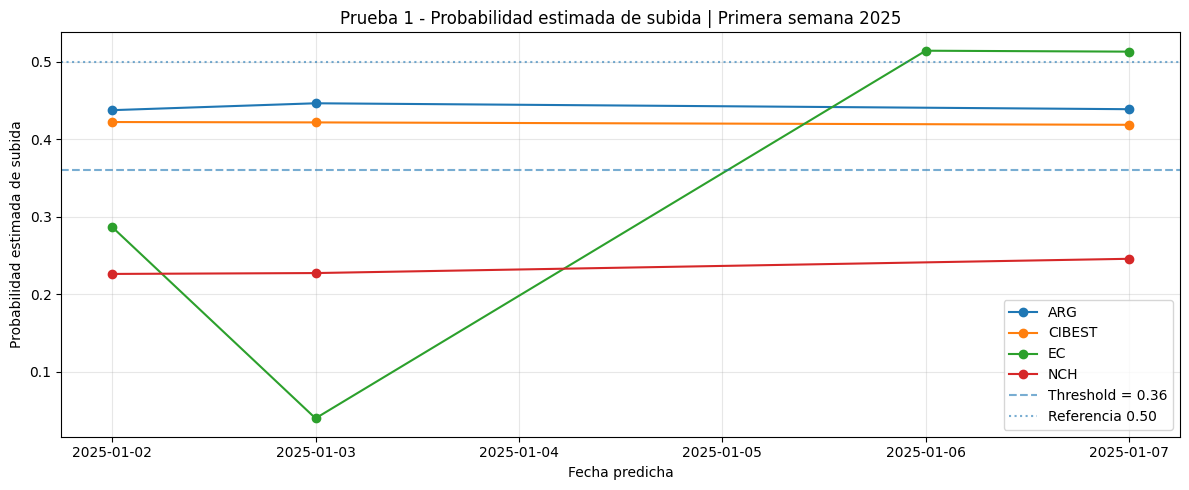

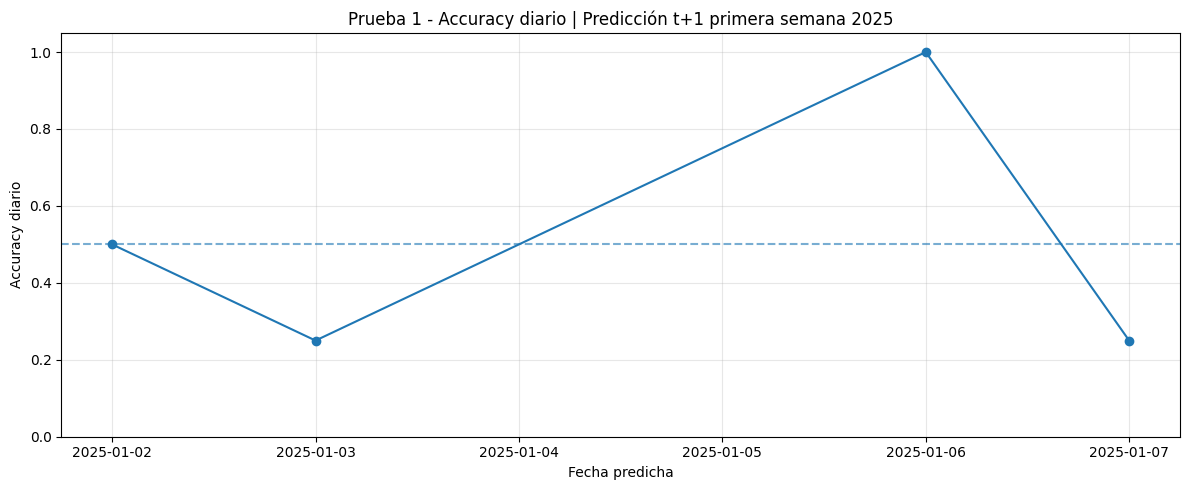

,fecha_predicha,accuracy_diario,predicciones
0,2025-01-02,0.50,4
1,2025-01-03,0.25,4
2,2025-01-06,1.00,1
3,2025-01-07,0.25,4


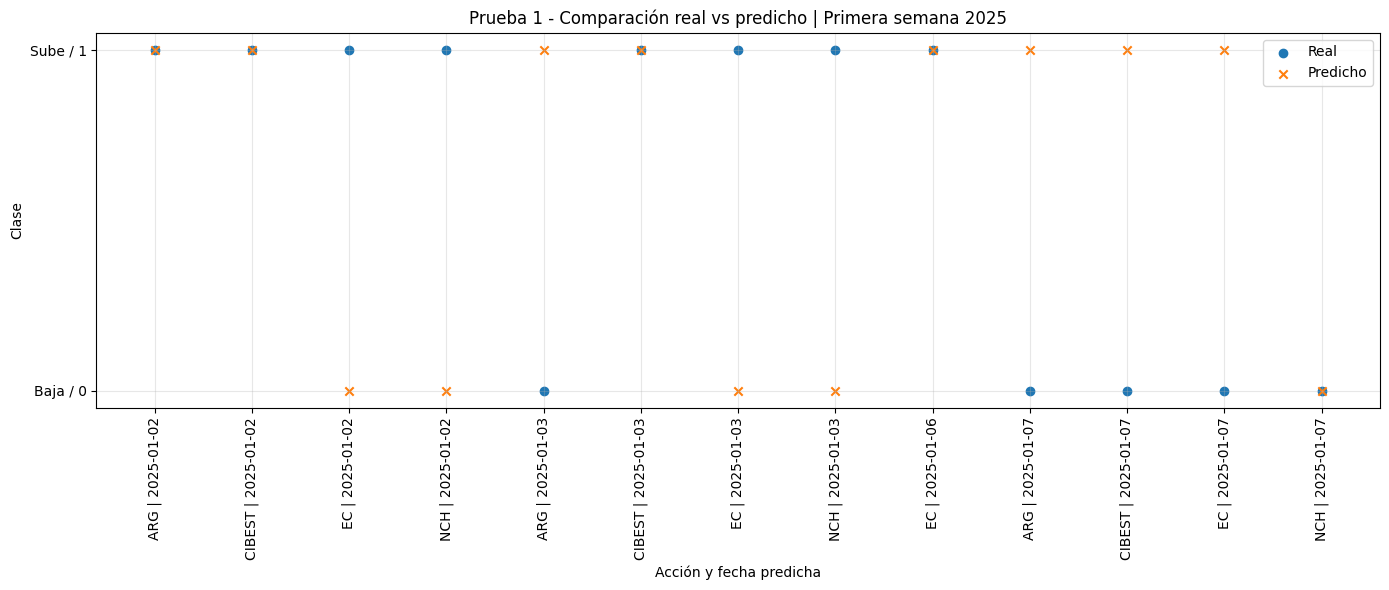

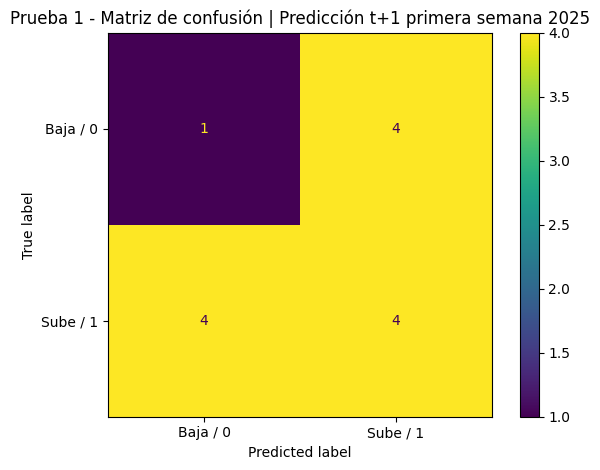

In [25]:

### Probabilidad estimada por acción
plt.figure(figsize=(12, 5))

for stock, g in pred_first_week_df.groupby("stock"):
    g = g.sort_values("fecha_predicha")
    plt.plot(
        g["fecha_predicha"],
        g["y_prob"],
        marker="o",
        label=stock
    )

plt.axhline(threshold_p1, linestyle="--", alpha=0.6, label=f"Threshold = {threshold_p1:.2f}")
plt.axhline(0.50, linestyle=":", alpha=0.6, label="Referencia 0.50")
plt.title("Prueba 1 - Probabilidad estimada de subida | Primera semana 2025")
plt.xlabel("Fecha predicha")
plt.ylabel("Probabilidad estimada de subida")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "prueba_1_probabilidad_subida_t1_primera_semana_2025.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Accuracy diario

daily_first_week_df = (
    pred_first_week_df
    .groupby("fecha_predicha", as_index=False)
    .agg(
        accuracy_diario=("correcto", "mean"),
        predicciones=("correcto", "count")
    )
)

plt.figure(figsize=(12, 5))
plt.plot(
    daily_first_week_df["fecha_predicha"],
    daily_first_week_df["accuracy_diario"],
    marker="o"
)

plt.axhline(0.50, linestyle="--", alpha=0.6)
plt.title("Prueba 1 - Accuracy diario | Predicción t+1 primera semana 2025")
plt.xlabel("Fecha predicha")
plt.ylabel("Accuracy diario")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "prueba_1_accuracy_diario_t1_primera_semana_2025.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

display(daily_first_week_df)


### Comparación real vs predicho

plot_compare_df = pred_first_week_df.copy()
plot_compare_df["id"] = (
    plot_compare_df["stock"] + " | " +
    plot_compare_df["fecha_predicha"].dt.strftime("%Y-%m-%d")
)

plt.figure(figsize=(14, 6))

x = np.arange(len(plot_compare_df))

plt.scatter(x, plot_compare_df["target_real"], marker="o", label="Real")
plt.scatter(x, plot_compare_df["y_pred"], marker="x", label="Predicho")

plt.xticks(x, plot_compare_df["id"], rotation=90)
plt.yticks([0, 1], ["Baja / 0", "Sube / 1"])
plt.title("Prueba 1 - Comparación real vs predicho | Primera semana 2025")
plt.xlabel("Acción y fecha predicha")
plt.ylabel("Clase")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "prueba_1_real_vs_predicho_t1_primera_semana_2025.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Matriz de confusión

cm = confusion_matrix(
    pred_first_week_df["target_real"],
    pred_first_week_df["y_pred"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Baja / 0", "Sube / 1"]
)

disp.plot(values_format="d")
plt.title("Prueba 1 - Matriz de confusión | Predicción t+1 primera semana 2025")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "prueba_1_matriz_confusion_t1_primera_semana_2025.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [26]:
### Saving
pred_first_week_path = os.path.join(
    OUTPUT_DIR,
    "prueba_1_predicciones_t1_primera_semana_2025_embeddings_dia_anterior.csv"
)

metrics_first_week_path = os.path.join(
    OUTPUT_DIR,
    "prueba_1_metricas_t1_primera_semana_2025_embeddings_dia_anterior.json"
)

metrics_first_week_stock_path = os.path.join(
    OUTPUT_DIR,
    "prueba_1_metricas_por_accion_t1_primera_semana_2025.csv"
)

pred_first_week_df.to_csv(pred_first_week_path, index=False)
metrics_first_week_stock_df.to_csv(metrics_first_week_stock_path, index=False)

with open(metrics_first_week_path, "w", encoding="utf-8") as f:
    json.dump(metrics_first_week, f, ensure_ascii=False, indent=4)

print("Predicciones guardadas en:", pred_first_week_path)
print("Métricas globales guardadas en:", metrics_first_week_path)
print("Métricas por acción guardadas en:", metrics_first_week_stock_path)

Predicciones guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_1_predicciones_t1_primera_semana_2025_embeddings_dia_anterior.csv
Métricas globales guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_1_metricas_t1_primera_semana_2025_embeddings_dia_anterior.json
Métricas por acción guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_1_metricas_por_accion_t1_primera_semana_2025.csv


## Prueba 2 - Rollin´horizon

Rollin horizon durante 2025

Modelo rolling: Logistic_Regression
Escenario rolling: C_embeddings
Cantidad de features rolling: 435
Tipo de features: features_modelo_ganador
Cantidad de fechas a predecir en 2025: 259
Reentrenando modelo para periodo 2025-01-02 00:00:00...
Reentrenando modelo para periodo 2025-01-03 00:00:00...
Reentrenando modelo para periodo 2025-01-06 00:00:00...
Reentrenando modelo para periodo 2025-01-07 00:00:00...
Reentrenando modelo para periodo 2025-01-08 00:00:00...
Reentrenando modelo para periodo 2025-01-09 00:00:00...
Reentrenando modelo para periodo 2025-01-10 00:00:00...
Reentrenando modelo para periodo 2025-01-13 00:00:00...
Reentrenando modelo para periodo 2025-01-14 00:00:00...
Reentrenando modelo para periodo 2025-01-15 00:00:00...
Reentrenando modelo para periodo 2025-01-16 00:00:00...
Reentrenando modelo para periodo 2025-01-17 00:00:00...
Reentrenando modelo para periodo 2025-01-20 00:00:00...
Reentrenando modelo para periodo 2025-01-21 00:00:00...
Reentrenando modelo para peri

,fecha,stock,target,y_prob,y_pred,correcto,threshold,periodo_entrenamiento
0,2025-01-02,ARG,1,0.441472,1,1,0.41,2025-01-02 00:00:00
1,2025-01-02,CIBEST,1,0.440673,1,1,0.41,2025-01-02 00:00:00
2,2025-01-02,EC,1,0.022571,0,0,0.41,2025-01-02 00:00:00
3,2025-01-02,NCH,1,0.221112,0,0,0.41,2025-01-02 00:00:00
4,2025-01-03,ARG,0,0.369547,0,1,0.41,2025-01-03 00:00:00


Total predicciones rolling: (996, 8)
RESULTADOS PRUEBA 2 - ROLLING HORIZON 2025
accuracy: 0.5612
balanced_accuracy: 0.5656
f1: 0.5563
precision: 0.5112
recall: 0.6102
mcc: 0.1310
roc_auc: 0.5781


,stock,n,accuracy,balanced_accuracy,f1,precision,recall,mcc,roc_auc
2,EC,250,0.576000,0.560375,0.668750,0.572193,0.804511,0.138777,0.591479
0,ARG,251,0.517928,0.544697,0.556777,0.455090,0.716981,0.093573,0.546779
3,NCH,251,0.657371,0.508351,0.065217,0.500000,0.034884,0.051892,0.443270
1,CIBEST,244,0.491803,0.488172,0.586667,0.500000,0.709677,-0.026377,0.515255


,mes,n,accuracy,balanced_accuracy,f1,precision,recall,mcc,roc_auc
0,2025-01,83,0.614458,0.607602,0.555556,0.588235,0.526316,0.218028,0.639181
1,2025-02,79,0.493671,0.491634,0.459459,0.459459,0.459459,-0.016731,0.480051
2,2025-03,83,0.542169,0.543314,0.547619,0.522727,0.575000,0.086729,0.544767
3,2025-04,85,0.611765,0.607993,0.560000,0.538462,0.583333,0.214173,0.574263
4,2025-05,86,0.534884,0.536255,0.555556,0.520833,0.595238,0.072986,0.584957
5,2025-06,76,0.592105,0.617388,0.575342,0.477273,0.724138,0.230994,0.639765
6,2025-07,91,0.593407,0.622033,0.574713,0.471698,0.735294,0.239417,0.552632
7,2025-08,80,0.600000,0.598499,0.627907,0.600000,0.658537,0.198493,0.641026
8,2025-09,87,0.528736,0.536765,0.506024,0.446809,0.583333,0.072664,0.523965
9,2025-10,89,0.516854,0.496939,0.612613,0.548387,0.693878,-0.006625,0.583163


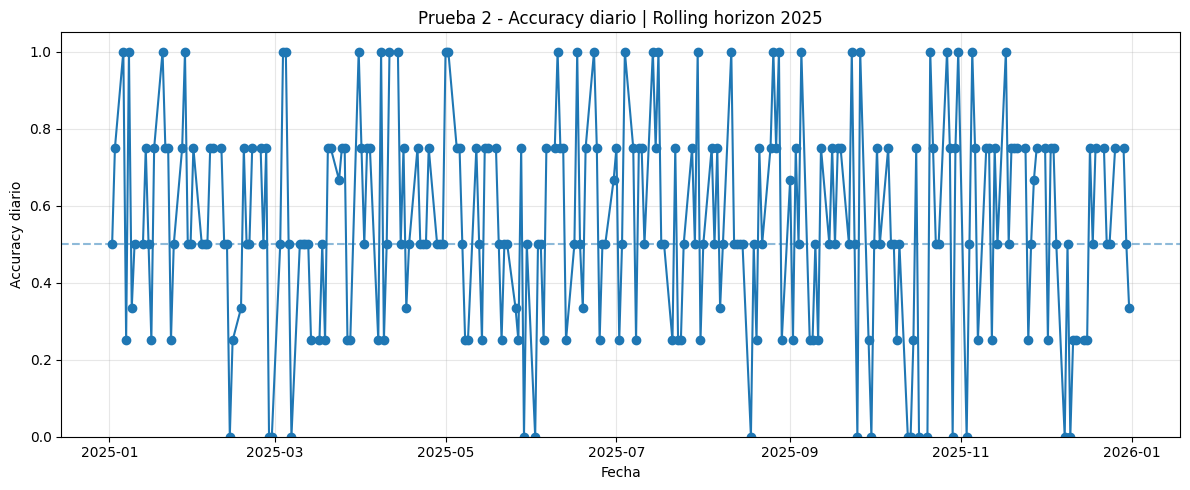

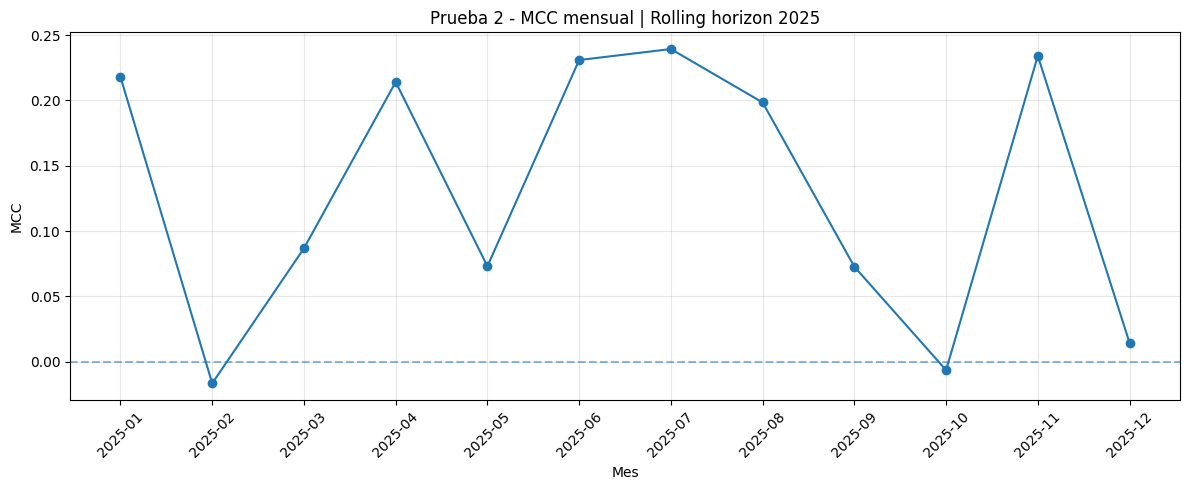

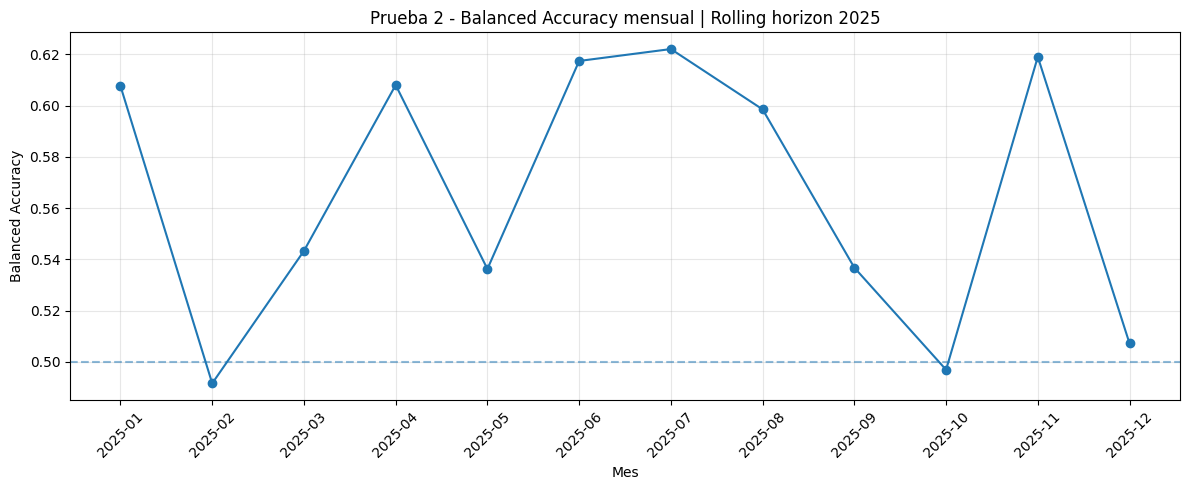

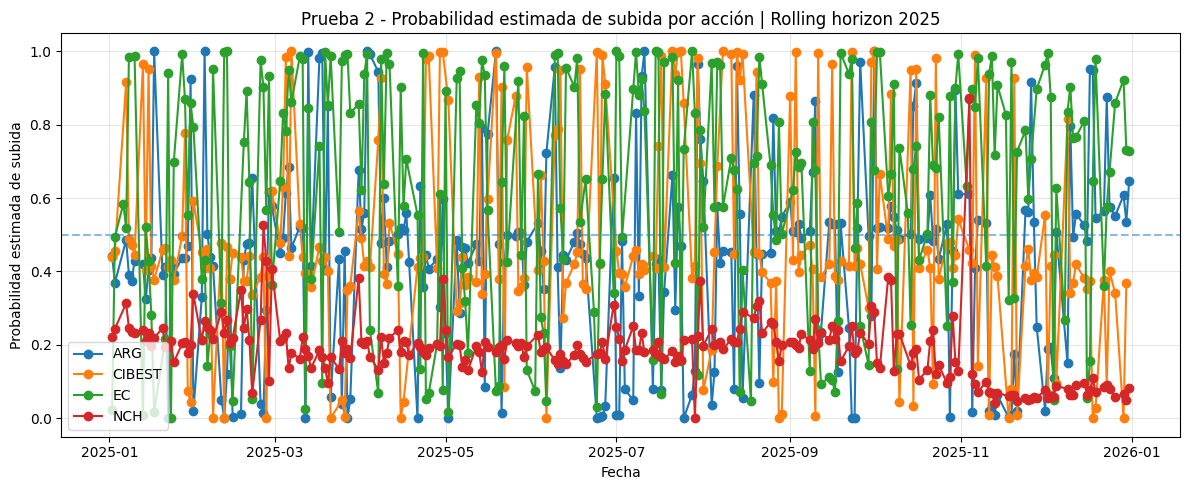

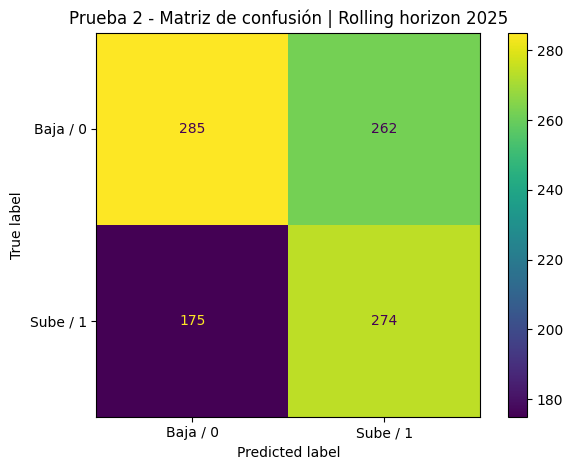

Predicciones rolling guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_2_predicciones_rolling_horizon_2025.csv
Métricas rolling guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_2_metricas_rolling_horizon_2025.json
Métricas mensuales guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_2_metricas_mensuales_rolling_horizon_2025.csv
Métricas por acción guardadas en: /content/drive/MyDrive/EAFIT/TESIS/RZK/prueba_2_metricas_por_accion_rolling_horizon_2025.csv


In [27]:
### Configuración del rollin´ horizon
ROLLING_START = pd.Timestamp("2025-01-01")
ROLLING_END = pd.Timestamp("2025-12-31")

RETRAIN_FREQUENCY = "D"
# 'D entrena diariamente***'

USE_ONLY_EMBEDDINGS_ROLLING = False

if USE_ONLY_EMBEDDINGS_ROLLING:
    rolling_features = emb_cols
    rolling_feature_label = "solo_embeddings"
else:
    if BEST_SCENARIO == "A_tecnico":
        rolling_features = technical_features
    elif BEST_SCENARIO == "B_sentimiento_agregado":
        rolling_features = sentiment_features
    elif BEST_SCENARIO == "C_embeddings":
        rolling_features = embedding_features
    else:
        rolling_features = embedding_features

    rolling_features = [c for c in rolling_features if c in df_model.columns and c != "stock"]
    rolling_feature_label = "features_modelo_ganador"

print("Modelo rolling:", BEST_MODEL_NAME)
print("Escenario rolling:", BEST_SCENARIO)
print("Cantidad de features rolling:", len(rolling_features))
print("Tipo de features:", rolling_feature_label)


### Preparar fechas objetivo de 2025

df_rolling = df_model.copy()
df_rolling["fecha"] = pd.to_datetime(df_rolling["fecha"])

rolling_dates = sorted(
    df_rolling[
        (df_rolling["fecha"] >= ROLLING_START) &
        (df_rolling["fecha"] <= ROLLING_END)
    ]["fecha"].unique()
)

print("Cantidad de fechas a predecir en 2025:", len(rolling_dates))

if len(rolling_dates) == 0:
    raise ValueError("No hay fechas disponibles para 2025.")

### Ejecutar rolling horizon

rolling_predictions = []

current_model = None
current_threshold = None
current_period = None

for current_date in rolling_dates:

    current_date = pd.Timestamp(current_date)

    train_hist = df_rolling[df_rolling["fecha"] < current_date].copy()
    test_day = df_rolling[df_rolling["fecha"] == current_date].copy()

    if len(train_hist) == 0 or len(test_day) == 0:
        continue

    hist_dates = np.array(sorted(train_hist["fecha"].unique()))

    if len(hist_dates) < 50:
        continue

    val_size = max(int(len(hist_dates) * 0.20), 10)

    train_dates_roll = hist_dates[:-val_size]
    val_dates_roll = hist_dates[-val_size:]

    train_roll = train_hist[train_hist["fecha"].isin(train_dates_roll)].copy()
    val_roll = train_hist[train_hist["fecha"].isin(val_dates_roll)].copy()

    # Definir cuándo reentrenar
    if RETRAIN_FREQUENCY == "D":
        period_key = current_date

    elif RETRAIN_FREQUENCY == "M":
        period_key = current_date.to_period("M")

    else:
        raise ValueError("RETRAIN_FREQUENCY debe ser 'D' o 'M'.")

    should_retrain = current_model is None or period_key != current_period

    if should_retrain:

        print(f"Reentrenando modelo para periodo {period_key}...")

        if BEST_MODEL_NAME in [
            "Dummy_Most_Frequent",
            "Dummy_Stratified",
            "Logistic_Regression",
            "Random_Forest",
            "Gradient_Boosting",
            "XGBoost"
        ]:

            current_model, current_threshold = train_classic_for_period(
                model_name=BEST_MODEL_NAME,
                train_data=train_roll,
                val_data=val_roll,
                features=rolling_features
            )

        else:
            raise ValueError(
                f"""
                El modelo ganador detectado fue {BEST_MODEL_NAME}.
                Este bloque rolling está implementado para modelos clásicos.
                Para LSTM/CNN/GNN se recomienda crear un rolling específico por secuencias,
                porque el reentrenamiento diario puede ser muy costoso.
                """
            )

        current_period = period_key

    # Predicción del día actual
    if hasattr(current_model.named_steps["model"], "predict_proba"):
        y_prob_day = current_model.predict_proba(test_day[rolling_features])[:, 1]
    else:
        y_prob_day = current_model.predict(test_day[rolling_features])

    pred_day_df = build_prediction_dataframe(
        df_eval=test_day,
        y_prob=y_prob_day,
        threshold=current_threshold
    )

    pred_day_df["threshold"] = current_threshold
    pred_day_df["periodo_entrenamiento"] = str(current_period)

    rolling_predictions.append(pred_day_df)


### Consolidación predicciones rolling horizon

if len(rolling_predictions) == 0:
    raise ValueError("No se generaron predicciones en el rolling horizon.")

rolling_pred_df = pd.concat(rolling_predictions, ignore_index=True)

display(rolling_pred_df.head())
print("Total predicciones rolling:", rolling_pred_df.shape)


### Metricas globales
rolling_metrics = evaluate_predictions(
    rolling_pred_df[TARGET_COL],
    y_prob=rolling_pred_df["y_prob"],
    threshold=0.50
)

rolling_metrics_dynamic_threshold = {
    "accuracy": accuracy_score(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"]),
    "balanced_accuracy": balanced_accuracy_score(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"]),
    "f1": f1_score(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"], zero_division=0),
    "precision": precision_score(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"], zero_division=0),
    "recall": recall_score(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"], zero_division=0),
    "mcc": matthews_corrcoef(rolling_pred_df[TARGET_COL], rolling_pred_df["y_pred"]),
}

try:
    rolling_metrics_dynamic_threshold["roc_auc"] = roc_auc_score(
        rolling_pred_df[TARGET_COL],
        rolling_pred_df["y_prob"]
    )
except:
    rolling_metrics_dynamic_threshold["roc_auc"] = np.nan

print("=" * 90)
print("RESULTADOS PRUEBA 2 - ROLLING HORIZON 2025")
print("=" * 90)

for k, v in rolling_metrics_dynamic_threshold.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


### Métricas por acción
rolling_by_stock = []

for stock, g in rolling_pred_df.groupby("stock"):

    stock_metrics = {
        "stock": stock,
        "n": len(g),
        "accuracy": accuracy_score(g[TARGET_COL], g["y_pred"]),
        "balanced_accuracy": balanced_accuracy_score(g[TARGET_COL], g["y_pred"]),
        "f1": f1_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "precision": precision_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "recall": recall_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "mcc": matthews_corrcoef(g[TARGET_COL], g["y_pred"]),
    }

    try:
        stock_metrics["roc_auc"] = roc_auc_score(g[TARGET_COL], g["y_prob"])
    except:
        stock_metrics["roc_auc"] = np.nan

    rolling_by_stock.append(stock_metrics)

rolling_by_stock_df = pd.DataFrame(rolling_by_stock).sort_values("mcc", ascending=False)

display(rolling_by_stock_df)


### Métricas por mes

rolling_pred_df["mes"] = rolling_pred_df["fecha"].dt.to_period("M").astype(str)

rolling_monthly = []

for mes, g in rolling_pred_df.groupby("mes"):

    monthly_metrics = {
        "mes": mes,
        "n": len(g),
        "accuracy": accuracy_score(g[TARGET_COL], g["y_pred"]),
        "balanced_accuracy": balanced_accuracy_score(g[TARGET_COL], g["y_pred"]),
        "f1": f1_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "precision": precision_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "recall": recall_score(g[TARGET_COL], g["y_pred"], zero_division=0),
        "mcc": matthews_corrcoef(g[TARGET_COL], g["y_pred"]),
    }

    try:
        monthly_metrics["roc_auc"] = roc_auc_score(g[TARGET_COL], g["y_prob"])
    except:
        monthly_metrics["roc_auc"] = np.nan

    rolling_monthly.append(monthly_metrics)

rolling_monthly_df = pd.DataFrame(rolling_monthly)

display(rolling_monthly_df)


### Gráfico para rollin´ horizon

daily_rolling_df = plot_predictions_by_date(
    rolling_pred_df,
    title="Prueba 2 - Accuracy diario | Rolling horizon 2025",
    output_path=os.path.join(OUTPUT_DIR, "prueba_2_accuracy_diario_rolling_2025.png")
)

plt.figure(figsize=(12, 5))
plt.plot(rolling_monthly_df["mes"], rolling_monthly_df["mcc"], marker="o")
plt.axhline(0.00, linestyle="--", alpha=0.5)
plt.title("Prueba 2 - MCC mensual | Rolling horizon 2025")
plt.xlabel("Mes")
plt.ylabel("MCC")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prueba_2_mcc_mensual_rolling_2025.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(rolling_monthly_df["mes"], rolling_monthly_df["balanced_accuracy"], marker="o")
plt.axhline(0.50, linestyle="--", alpha=0.5)
plt.title("Prueba 2 - Balanced Accuracy mensual | Rolling horizon 2025")
plt.xlabel("Mes")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prueba_2_balanced_accuracy_mensual_rolling_2025.png"), dpi=300, bbox_inches="tight")
plt.show()


plot_probabilities(
    rolling_pred_df,
    title="Prueba 2 - Probabilidad estimada de subida por acción | Rolling horizon 2025",
    output_path=os.path.join(OUTPUT_DIR, "prueba_2_probabilidades_rolling_2025.png")
)

plot_confusion_matrix_from_df(
    rolling_pred_df,
    title="Prueba 2 - Matriz de confusión | Rolling horizon 2025",
    output_path=os.path.join(OUTPUT_DIR, "prueba_2_matriz_confusion_rolling_2025.png")
)


### Saving

rolling_pred_path = os.path.join(
    OUTPUT_DIR,
    "prueba_2_predicciones_rolling_horizon_2025.csv"
)

rolling_metrics_path = os.path.join(
    OUTPUT_DIR,
    "prueba_2_metricas_rolling_horizon_2025.json"
)

rolling_monthly_path = os.path.join(
    OUTPUT_DIR,
    "prueba_2_metricas_mensuales_rolling_horizon_2025.csv"
)

rolling_stock_path = os.path.join(
    OUTPUT_DIR,
    "prueba_2_metricas_por_accion_rolling_horizon_2025.csv"
)

rolling_pred_df.to_csv(rolling_pred_path, index=False)
rolling_monthly_df.to_csv(rolling_monthly_path, index=False)
rolling_by_stock_df.to_csv(rolling_stock_path, index=False)

with open(rolling_metrics_path, "w", encoding="utf-8") as f:
    json.dump(rolling_metrics_dynamic_threshold, f, ensure_ascii=False, indent=4)

print("Predicciones rolling guardadas en:", rolling_pred_path)
print("Métricas rolling guardadas en:", rolling_metrics_path)
print("Métricas mensuales guardadas en:", rolling_monthly_path)
print("Métricas por acción guardadas en:", rolling_stock_path)